# 1\.5\.3 Engineer Multimodal Interaction Features

This notebook builds multimodal interaction features that capture how different transportation systems behave relative to one another within the same Taxi Zone, date, and temporal bucket\. Starting from the spatially enriched mobility panel created in 1\.5\.2, we create cross\-modal ratios, mobility\-share measures, local\-versus\-neighborhood divergence indicators, bridge and tunnel interaction features, and a small set of Traffic\-specific features designed for its irregular observation schedule\. The goal is to better characterize mobility states, transportation substitution patterns, and system\-level interactions that may support downstream clustering, anomaly detection, congestion\-pricing analysis, and traffic\-imputation modeling\.

In [1]:
# 1.5.3 Engineer Multimodal Interaction Features

from pathlib import Path
import json
import math
import warnings

import duckdb
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)

In [2]:
# -------------------------------------------------------------------
# Project paths
# -------------------------------------------------------------------

WRITE_OUTPUTS = True

PIPELINE_DATA_DIR = Path("pipeline_data")

SPATIAL_INPUT_DIR = PIPELINE_DATA_DIR / "1.5.2.final_tables"
SPATIAL_INPUT_DIR = PIPELINE_DATA_DIR / "1.5.2.final_tables"
BRIDGE_TUNNEL_INPUT_DIR = PIPELINE_DATA_DIR / "1.3.1.final_tables"

OUTPUT_DIR = PIPELINE_DATA_DIR / "1.5.3.final_tables"
INTERMEDIATE_DIR = PIPELINE_DATA_DIR / "1.5.3.intermediate_tables"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
INTERMEDIATE_DIR.mkdir(parents=True, exist_ok=True)

SPATIAL_PANEL_PATH = SPATIAL_INPUT_DIR / "spatial_mobility_feature_panel.parquet"
SPATIAL_FEATURE_MANIFEST_PATH = SPATIAL_INPUT_DIR / "spatial_feature_manifest.csv"
SPATIAL_FEATURE_QA_PATH = SPATIAL_INPUT_DIR / "spatial_feature_qa_summary.csv"

BRIDGE_TUNNEL_PANEL_PATH = BRIDGE_TUNNEL_INPUT_DIR / "bridge_tunnel_mobility_panel.parquet"

OUTPUT_PANEL_PATH = OUTPUT_DIR / "multimodal_interaction_feature_panel.parquet"
OUTPUT_MANIFEST_PATH = OUTPUT_DIR / "multimodal_interaction_feature_manifest.csv"
OUTPUT_QA_PATH = OUTPUT_DIR / "multimodal_interaction_feature_qa_summary.csv"

BRIDGE_TUNNEL_CONTEXT_PATH = INTERMEDIATE_DIR / "bridge_tunnel_temporal_context.parquet"

In [3]:
# -------------------------------------------------------------------
# Modeling grain and key columns
# -------------------------------------------------------------------

GRAIN_COLUMNS = [
    "taxi_zone_id",
    "date",
    "temporal_bucket",
]

TEMPORAL_JOIN_COLUMNS = [
    "date",
    "temporal_bucket",
]

METADATA_COLUMNS = [
    "taxi_zone_id",
    "zone",
    "borough",
    "canonical_location_id",
    "date",
    "year",
    "month",
    "day_of_week",
    "temporal_bucket",
    "pre_post_cp",
]

CP_START_DATE = pd.to_datetime("2025-01-05").date()

In [4]:
# -------------------------------------------------------------------
# Core mobility metrics
# -------------------------------------------------------------------

LOCAL_MOBILITY_METRICS = [
    "traffic_volume",
    "bus_trip_count",
    "avg_bus_speed",
    "avg_bus_travel_time",
    "subway_ridership",
    "subway_transfers",
    "taxi_trip_count",
    "taxi_avg_trip_distance",
    "taxi_avg_trip_duration",
    "taxi_avg_trip_speed",
    "taxi_distinct_dropoff_zone_count",
    "fhvhv_trip_count",
    "fhvhv_avg_trip_distance",
    "fhvhv_avg_trip_duration",
    "fhvhv_avg_trip_speed",
    "fhvhv_distinct_dropoff_zone_count",
]

DEMAND_METRICS = [
    "traffic_volume",
    "bus_trip_count",
    "subway_ridership",
    "taxi_trip_count",
    "fhvhv_trip_count",
]

TRANSIT_DEMAND_METRICS = [
    "subway_ridership",
    "bus_trip_count",
]

FOR_HIRE_DEMAND_METRICS = [
    "taxi_trip_count",
    "fhvhv_trip_count",
]

CONNECTED_METRICS = [
    f"connected_mean_{metric}" for metric in LOCAL_MOBILITY_METRICS
]

BOROUGH_CONTEXT_METRICS = [
    f"borough_mean_{metric}" for metric in LOCAL_MOBILITY_METRICS
]

CP_ZONE_CONTEXT_METRICS = [
    f"cp_zone_mean_{metric}" for metric in LOCAL_MOBILITY_METRICS
]

In [5]:
# -------------------------------------------------------------------
# Feature engineering controls
# -------------------------------------------------------------------

EPSILON = 1e-6

CREATE_TRAFFIC_SPARSE_TEMPORAL_FEATURES = True
CREATE_MODAL_RATIO_FEATURES = True
CREATE_MODAL_SHARE_FEATURES = True
CREATE_STANDARDIZED_IMBALANCE_FEATURES = True
CREATE_CONNECTED_ZONE_DIVERGENCE_FEATURES = True
CREATE_BRIDGE_TUNNEL_INTERACTION_FEATURES = True

# Keep the notebook MVP-focused. Avoid exploding every possible pair.
MODAL_RATIO_PAIRS = [
    ("traffic_volume", "subway_ridership"),
    ("traffic_volume", "taxi_trip_count"),
    ("traffic_volume", "fhvhv_trip_count"),
    ("traffic_volume", "bus_trip_count"),
    ("taxi_trip_count", "subway_ridership"),
    ("fhvhv_trip_count", "subway_ridership"),
    ("taxi_trip_count", "bus_trip_count"),
    ("fhvhv_trip_count", "bus_trip_count"),
]

STANDARDIZED_IMBALANCE_PAIRS = [
    ("traffic_volume", "subway_ridership"),
    ("taxi_trip_count", "subway_ridership"),
    ("fhvhv_trip_count", "subway_ridership"),
    ("traffic_volume", "bus_trip_count"),
    ("taxi_trip_count", "bus_trip_count"),
    ("fhvhv_trip_count", "bus_trip_count"),
]

In [6]:
# -------------------------------------------------------------------
# Input validation
# -------------------------------------------------------------------

required_paths = {
    "Spatial mobility feature panel": SPATIAL_PANEL_PATH,
    "Spatial feature manifest": SPATIAL_FEATURE_MANIFEST_PATH,
    "Spatial feature QA summary": SPATIAL_FEATURE_QA_PATH,
    "Bridge/tunnel mobility panel": BRIDGE_TUNNEL_PANEL_PATH,
}

for label, path in required_paths.items():
    print(f"{label}: {path.exists()} | {path}")

Spatial mobility feature panel: True | pipeline_data/1.5.2.final_tables/spatial_mobility_feature_panel.parquet
Spatial feature manifest: True | pipeline_data/1.5.2.final_tables/spatial_feature_manifest.csv
Spatial feature QA summary: True | pipeline_data/1.5.2.final_tables/spatial_feature_qa_summary.csv
Bridge/tunnel mobility panel: True | pipeline_data/1.3.1.final_tables/bridge_tunnel_mobility_panel.parquet


## 1\.5\.3\.1 Bridge & Tunnel Context Preparation

We start by loading the spatial mobility panel and Bridge & Tunnel panel into dataframes so we can inspect their structure before creating new features\. The main goal of this check is simple: confirm that the 1\.5\.2 panel still has the expected Taxi Zone × Date × Temporal Bucket grain, confirm that Bridge & Tunnel is available as a separate date × temporal bucket context source, and make sure the two inputs cover the same study period before we join anything together\.

### Load and Inspect B&T Data

In [7]:
# -------------------------------------------------------------------
# Quick source-table orientation
# -------------------------------------------------------------------

spatial_panel_df = pd.read_parquet(SPATIAL_PANEL_PATH)
bridge_tunnel_df = pd.read_parquet(BRIDGE_TUNNEL_PANEL_PATH)

spatial_summary = pd.DataFrame({
    "row_count": [len(spatial_panel_df)],
    "taxi_zones": [spatial_panel_df["taxi_zone_id"].nunique()],
    "min_date": [spatial_panel_df["date"].min()],
    "max_date": [spatial_panel_df["date"].max()],
    "temporal_buckets": [spatial_panel_df["temporal_bucket"].nunique()],
    "cp_periods": [spatial_panel_df["pre_post_cp"].nunique()],
})

bridge_tunnel_summary = pd.DataFrame({
    "row_count": [len(bridge_tunnel_df)],
    "min_date": [bridge_tunnel_df["date"].min()],
    "max_date": [bridge_tunnel_df["date"].max()],
    "facilities": [bridge_tunnel_df["facility"].nunique()],
    "directions": [bridge_tunnel_df["direction"].nunique()],
    "temporal_buckets": [bridge_tunnel_df["temporal_bucket"].nunique()],
})

display(spatial_summary)
display(bridge_tunnel_summary)

,row_count,taxi_zones,min_date,max_date,temporal_buckets,cp_periods
0,1559590,263,2023-01-01,2026-03-31,10,2


,row_count,min_date,max_date,facilities,directions,temporal_buckets
0,112657,2023-01-01,2026-03-31,10,15,10


Findings\. The spatial mobility panel and Bridge & Tunnel panel cover the same study period and temporal framework, providing complete alignment for multimodal interaction feature engineering and bridge/tunnel context integration\.

Bridge & Tunnel data currently exists at the Facility × Direction × Date × Temporal Bucket grain, which is too detailed for direct use in the Taxi Zone mobility panel\. In this section, we aggregate crossings into a small set of system\-level mobility signals that can be joined onto every Taxi Zone observation and used to measure how local mobility conditions relate to regional travel flows into and out of Manhattan\.

In [8]:
facility_direction_df = (
    bridge_tunnel_df
    .groupby(["facility", "direction"], dropna=False)
    .agg(
        observation_count=("bridge_tunnel_volume", "size"),
        total_volume=("bridge_tunnel_volume", "sum")
    )
    .sort_values("total_volume", ascending=False)
    .reset_index()
)

display(facility_direction_df)

,facility,direction,observation_count,total_volume
0,Verrazzano - Narrows Bridge,Eastbound to Brooklyn,5930,131654039.0
1,Verrazzano - Narrows Bridge,Westbound to Staten Island,5930,129614887.0
2,Robert F. Kennedy Bridge Bronx,Northbound to Manhattan or Bronx,5930,96955867.0
3,Bronx - Whitestone Bridge,Southbound to Queens,5930,83838082.0
4,Bronx - Whitestone Bridge,Northbound to Bronx,5930,78294738.0
5,Throgs Neck Bridge,Southbound to Queens,5930,74724193.0
6,Robert F. Kennedy Bridge Bronx,Southbound to Manhattan or Queens,5930,71732037.0
7,Throgs Neck Bridge,Northbound to Bronx,5930,69207162.0
8,Robert F. Kennedy Bridge Manhattan,Eastbound to Bronx or Queens,5930,54965263.0
9,Queens Midtown Tunnel,Westbound to Manhattan,5929,51738859.0


Finding: Bridge and Tunnel activity is concentrated in a small number of major regional crossings, led by the Verrazzano\-Narrows Bridge, RFK Bridge, Bronx\-Whitestone Bridge, and Throgs Neck Bridge, while tunnels and smaller bridge facilities contribute comparatively lower volumes\.

⚠️ Data Limitation: This dataset includes only MTA\-operated bridges and tunnels and excludes Port Authority crossings such as the George Washington Bridge, Lincoln Tunnel, and Holland Tunnel; therefore, Bridge & Tunnel features should be interpreted as regional MTA crossing demand rather than total vehicle access demand into Manhattan\.

Before creating bridge and tunnel interaction features, we first aggregate facility\-level crossing activity into a small set of date × temporal bucket mobility signals\. These aggregated measures provide regional roadway context that can later be compared against local traffic, transit demand, and for\-hire vehicle activity within individual Taxi Zones\.

In [9]:
MANHATTAN_CONNECTED_FACILITIES = [
    "Robert F. Kennedy Bridge Bronx",
    "Robert F. Kennedy Bridge Manhattan",
    "Queens Midtown Tunnel",
    "Henry Hudson Bridge",
    "Hugh L. Carey Tunnel",
]

bridge_tunnel_df["is_manhattan_connected_crossing"] = (
    bridge_tunnel_df["facility"].isin(MANHATTAN_CONNECTED_FACILITIES)
)

crossing_type_summary_df = (
    bridge_tunnel_df
    .groupby("is_manhattan_connected_crossing")
    .agg(
        observation_count=("bridge_tunnel_volume", "size"),
        total_volume=("bridge_tunnel_volume", "sum")
    )
    .reset_index()
)

crossing_type_summary_df["observation_percent"] = (
    crossing_type_summary_df["observation_count"] 
    / crossing_type_summary_df["observation_count"].sum()
).round(3)

crossing_type_summary_df["volume_percent"] = (
    crossing_type_summary_df["total_volume"] 
    / crossing_type_summary_df["total_volume"].sum()
).round(3)

display(crossing_type_summary_df)

,is_manhattan_connected_crossing,observation_count,total_volume,observation_percent,volume_percent
0,False,59300,618074255.0,0.526,0.565
1,True,53357,474948452.0,0.474,0.435


Finding: Nearly half of all MTA bridge and tunnel volume occurs on facilities that directly connect to Manhattan\. Rather than measuring only traffic traveling toward Manhattan, this classification captures total activity on Manhattan\-connected crossings in both directions, providing a more complete measure of roadway demand associated with Manhattan travel and access\.

### Collapse Facilities

Before creating bridge and tunnel interaction features, we first collapse facility\-level crossing records into a compact date × temporal bucket context table\. This gives each mobility\-state observation the same regional MTA crossing context, while keeping the feature set focused and avoiding facility\-level noise\.

In [10]:
# -------------------------------------------------------------------
# Create Bridge & Tunnel temporal context table
# -------------------------------------------------------------------

bridge_tunnel_df["is_manhattan_connected_crossing"] = (
    bridge_tunnel_df["facility"].isin(MANHATTAN_CONNECTED_FACILITIES)
)

bridge_tunnel_context_df = (
    bridge_tunnel_df
    .groupby(["date", "temporal_bucket"], as_index=False)
    .agg(
        total_mta_crossing_volume=("bridge_tunnel_volume", "sum"),
        manhattan_connected_mta_crossing_volume=(
            "bridge_tunnel_volume",
            lambda x: x[
                bridge_tunnel_df.loc[x.index, "is_manhattan_connected_crossing"]
            ].sum()
        ),
    )
)

bridge_tunnel_context_df["non_manhattan_connected_mta_crossing_volume"] = (
    bridge_tunnel_context_df["total_mta_crossing_volume"]
    - bridge_tunnel_context_df["manhattan_connected_mta_crossing_volume"]
)

bridge_tunnel_context_df["manhattan_connected_crossing_share"] = (
    bridge_tunnel_context_df["manhattan_connected_mta_crossing_volume"]
    / bridge_tunnel_context_df["total_mta_crossing_volume"].replace(0, np.nan)
).round(3)

display(bridge_tunnel_context_df.head())

,date,temporal_bucket,total_mta_crossing_volume,manhattan_connected_mta_crossing_volume,non_manhattan_connected_mta_crossing_volume,manhattan_connected_crossing_share
0,2023-01-01,weekend_am_peak,63623.0,23236.0,40387.0,0.365
1,2023-01-01,weekend_evening,113876.0,44645.0,69231.0,0.392
2,2023-01-01,weekend_midday,259529.0,104705.0,154824.0,0.403
3,2023-01-01,weekend_overnight,111874.0,50163.0,61711.0,0.448
4,2023-01-01,weekend_pm_peak,190930.0,78993.0,111937.0,0.414


Finding: The bridge/tunnel context table now captures total MTA crossing activity plus Manhattan\-connected facility volume by date and temporal bucket, with Manhattan\-connected crossings representing roughly 36%–45% of total MTA crossing volume in this sample\.

### Join Crossings Data

We've finished building and QA'ing the bridge/tunnel context table\. The next logical step is to attach those regional mobility signals to every Taxi Zone observation so that all subsequent feature engineering happens in a single dataframe\.

The Bridge & Tunnel context table captures regional crossing activity at the date × temporal bucket level and can now be joined onto the spatial mobility panel\. This gives every Taxi Zone observation access to the same regional roadway context and allows bridge/tunnel interaction features to be created alongside other multimodal features\.

In [11]:
# -------------------------------------------------------------------
# Align join-key types before merge
# -------------------------------------------------------------------

spatial_panel_df["date"] = pd.to_datetime(spatial_panel_df["date"])
bridge_tunnel_context_df["date"] = pd.to_datetime(bridge_tunnel_context_df["date"])

spatial_panel_df["temporal_bucket"] = spatial_panel_df["temporal_bucket"].astype(str)
bridge_tunnel_context_df["temporal_bucket"] = bridge_tunnel_context_df["temporal_bucket"].astype(str)

In [12]:
# -------------------------------------------------------------------
# Join Bridge & Tunnel context to spatial mobility panel
# -------------------------------------------------------------------

print(f"Columns before join: {len(spatial_panel_df.columns):,}")

spatial_panel_df = spatial_panel_df.merge(
    bridge_tunnel_context_df,
    on=["date", "temporal_bucket"],
    how="left",
    validate="many_to_one"
)

print(f"Columns after join: {len(spatial_panel_df.columns):,}")

Columns before join: 231
Columns after join: 235


Finding: The Bridge & Tunnel context table joined successfully to the spatial mobility panel with no change in row count, confirming that the original Taxi Zone × Date × Temporal Bucket grain was fully preserved\.

In [13]:
# -------------------------------------------------------------------
# QA Bridge & Tunnel context join
# -------------------------------------------------------------------

bridge_tunnel_join_qa_df = pd.DataFrame({
    "row_count": [len(spatial_panel_df)],
    "missing_total_mta_crossing_volume": [
        spatial_panel_df["total_mta_crossing_volume"].isna().sum()
    ],
    "missing_manhattan_connected_mta_crossing_volume": [
        spatial_panel_df["manhattan_connected_mta_crossing_volume"].isna().sum()
    ],
    "missing_non_manhattan_connected_mta_crossing_volume": [
        spatial_panel_df["non_manhattan_connected_mta_crossing_volume"].isna().sum()
    ],
    "missing_manhattan_connected_crossing_share": [
        spatial_panel_df["manhattan_connected_crossing_share"].isna().sum()
    ]
})

display(bridge_tunnel_join_qa_df)

,row_count,missing_total_mta_crossing_volume,missing_manhattan_connected_mta_crossing_volume,missing_non_manhattan_connected_mta_crossing_volume,missing_manhattan_connected_crossing_share
0,1559590,0,0,0,0


Finding: All Bridge & Tunnel context variables joined with complete coverage and no missing values across the full spatial mobility panel\.

### Section Summary

We transformed facility\-level Bridge & Tunnel records into a compact temporal context table and successfully joined the resulting regional crossing signals onto the spatial mobility panel\. The final context variables capture total MTA crossing activity, Manhattan\-connected crossing activity, and Manhattan\-connected crossing share for every date and temporal bucket while preserving the original Taxi Zone × Date × Temporal Bucket analytical grain\.

## 1\.5\.3\.2 Deferred Traffic\-Specific Sparse Temporal Features

Unlike the other mobility systems, Traffic observations are collected from a limited and evolving sensor network rather than a consistently observed citywide coverage framework\. Before creating Traffic\-specific temporal features, we first evaluate whether individual Taxi Zones have sufficient longitudinal coverage to support meaningful year\-over\-year comparisons\. This assessment focuses on observation availability across years and establishes the foundation for determining whether Traffic can be treated as a reliable temporal signal\.

### Traffic Temporal Coverage Assessment

We begin by examining how many years of Traffic observations are available for each Traffic\-monitored Taxi Zone\. Temporal features such as congestion\-pricing deltas, lagged values, and trend calculations require observations spanning multiple years\. Zones observed in only a single year cannot support these types of longitudinal analyses\.

In [14]:
# -------------------------------------------------------------------
# Traffic coverage by Taxi Zone and year
# -------------------------------------------------------------------

traffic_year_coverage_df = (
    spatial_panel_df
    .loc[spatial_panel_df["traffic_volume"].notna()]
    .groupby(
        ["taxi_zone_id", "zone", "borough", "year"],
        as_index=False
    )
    .agg(
        observations=("traffic_volume", "count")
    )
)

traffic_year_coverage_pivot_df = (
    traffic_year_coverage_df
    .pivot_table(
        index=["taxi_zone_id", "zone", "borough"],
        columns="year",
        values="observations",
        fill_value=0
    )
    .reset_index()
)

traffic_year_coverage_pivot_df.columns.name = None

traffic_year_coverage_pivot_df["years_observed"] = (
    traffic_year_coverage_pivot_df[[2023, 2024, 2025, 2026]]
    .gt(0)
    .sum(axis=1)
)

traffic_year_coverage_pivot_df["total_observations"] = (
    traffic_year_coverage_pivot_df[[2023, 2024, 2025, 2026]]
    .sum(axis=1)
)

display(
    traffic_year_coverage_pivot_df
    .sort_values(
        ["years_observed", "total_observations"],
        ascending=[False, False]
    )
)

,taxi_zone_id,zone,borough,2023,2024,2025,2026,years_observed,total_observations
46,76,East New York,Brooklyn,100.0,75.0,195.0,0.0,3,370.0
34,63,Cypress Hills,Brooklyn,105.0,35.0,70.0,0.0,3,210.0
74,124,Howard Beach,Queens,80.0,35.0,70.0,0.0,3,185.0
85,143,Lincoln Square West,Manhattan,4.0,70.0,75.0,0.0,3,149.0
124,232,Two Bridges/Seward Park,Manhattan,55.0,60.0,15.0,0.0,3,130.0
80,135,Kew Gardens Hills,Queens,10.0,35.0,70.0,0.0,3,115.0
36,65,Downtown Brooklyn/MetroTech,Brooklyn,10.0,5.0,40.0,0.0,3,55.0
123,229,Sutton Place/Turtle Bay North,Manhattan,5.0,15.0,15.0,0.0,3,35.0
20,36,Bushwick North,Brooklyn,30.0,253.0,0.0,0.0,2,283.0
97,168,Mott Haven/Port Morris,Bronx,70.0,0.0,150.0,0.0,2,220.0


Finding: Traffic temporal coverage is highly uneven across Taxi Zones\. Only 8 of 138 Traffic\-monitored zones contain observations spanning three years, while approximately 70% of zones are observed in only a single year, substantially limiting the feasibility of broad Traffic\-specific temporal feature engineering and motivating additional stability and reliability analysis\.

138 rows is a lot of rows to process\. Let's whittle this down to the borough level to assess coverage per borough\.

In [15]:
# -------------------------------------------------------------------
# Coverage summary by borough
# -------------------------------------------------------------------

traffic_coverage_borough_summary_df = (
    traffic_year_coverage_pivot_df
    .groupby("borough")
    .agg(
        traffic_zones=("taxi_zone_id", "count"),
        one_year_zones=("years_observed", lambda x: (x == 1).sum()),
        two_year_zones=("years_observed", lambda x: (x == 2).sum()),
        three_year_zones=("years_observed", lambda x: (x == 3).sum()),
    )
    .reset_index()
)

traffic_coverage_borough_summary_df["pct_one_year_zones"] = (
    traffic_coverage_borough_summary_df["one_year_zones"]
    / traffic_coverage_borough_summary_df["traffic_zones"]
).round(3)

display(traffic_coverage_borough_summary_df)

,borough,traffic_zones,one_year_zones,two_year_zones,three_year_zones,pct_one_year_zones
0,Bronx,22,17,5,0,0.773
1,Brooklyn,47,33,11,3,0.702
2,Manhattan,27,14,10,3,0.519
3,Queens,34,25,7,2,0.735
4,Staten Island,8,7,1,0,0.875


Finding: Traffic coverage is sparse across all boroughs\. Between 52% and 88% of Traffic\-monitored Taxi Zones contain observations from only a single year, while only 8 Taxi Zones citywide exhibit observations spanning three years\. Manhattan has the strongest multi\-year coverage, whereas Staten Island has the most limited historical coverage\.

For this check, we focus only on Taxi Zones with exactly two years of Traffic observations\. One\-year zones cannot support pre/post comparison, while three\-year zones already span both sides of congestion pricing\. The 34 two\-year zones are the ambiguous group where we need to know whether coverage is limited to the pre\-CP period, limited to the post\-CP period, or spans both\.

In [16]:
# -------------------------------------------------------------------
# Traffic CP coverage among two-year Traffic zones
# -------------------------------------------------------------------

traffic_two_year_coverage_df = (
    traffic_year_coverage_pivot_df
    .loc[traffic_year_coverage_pivot_df["years_observed"] == 2]
    .copy()
)

traffic_two_year_coverage_df = traffic_two_year_coverage_df.assign(
    has_pre_cp_observations=lambda df: (
        (df[2023] > 0) | (df[2024] > 0)
    ),
    has_post_cp_observations=lambda df: (
        (df[2025] > 0) | (df[2026] > 0)
    )
)

traffic_two_year_coverage_df["cp_coverage_type"] = np.select(
    [
        traffic_two_year_coverage_df["has_pre_cp_observations"]
        & traffic_two_year_coverage_df["has_post_cp_observations"],

        traffic_two_year_coverage_df["has_pre_cp_observations"]
        & ~traffic_two_year_coverage_df["has_post_cp_observations"],

        ~traffic_two_year_coverage_df["has_pre_cp_observations"]
        & traffic_two_year_coverage_df["has_post_cp_observations"],
    ],
    [
        "Pre + Post CP",
        "Pre-CP only",
        "Post-CP only",
    ],
    default="No Traffic observations"
)

traffic_two_year_cp_coverage_summary_df = (
    traffic_two_year_coverage_df
    .groupby(["borough", "cp_coverage_type"])
    .agg(
        taxi_zones=("taxi_zone_id", "count")
    )
    .reset_index()
    .pivot_table(
        index="borough",
        columns="cp_coverage_type",
        values="taxi_zones",
        fill_value=0
    )
    .reset_index()
)

traffic_two_year_cp_coverage_summary_df.columns.name = None

display(traffic_two_year_cp_coverage_summary_df)

,borough,Post-CP only,Pre + Post CP,Pre-CP only
0,Bronx,0.0,4.0,1.0
1,Brooklyn,0.0,7.0,4.0
2,Manhattan,1.0,4.0,5.0
3,Queens,0.0,4.0,3.0
4,Staten Island,0.0,1.0,0.0


Finding: Of the 34 Taxi Zones with two years of Traffic observations, 20 span both pre\- and post\-congestion\-pricing periods and can support direct policy comparisons\. The remaining 14 zones are concentrated entirely within either the pre\-CP period \(13 zones\) or post\-CP period \(1 zone\)\.

Promising Traffic zones are the zones with enough history to support at least some pre/post congestion\-pricing analysis\. This includes all three\-year zones plus two\-year zones that span both the pre\- and post\-CP periods\.

In [17]:
# -------------------------------------------------------------------
# Add CP coverage fields to all Traffic-covered zones
# -------------------------------------------------------------------

traffic_cp_coverage_df = (
    traffic_year_coverage_pivot_df
    .assign(
        has_pre_cp_observations=lambda df: (
            (df[2023] > 0) | (df[2024] > 0)
        ),
        has_post_cp_observations=lambda df: (
            (df[2025] > 0) | (df[2026] > 0)
        )
    )
)

traffic_cp_coverage_df["cp_coverage_type"] = np.select(
    [
        traffic_cp_coverage_df["has_pre_cp_observations"]
        & traffic_cp_coverage_df["has_post_cp_observations"],

        traffic_cp_coverage_df["has_pre_cp_observations"]
        & ~traffic_cp_coverage_df["has_post_cp_observations"],

        ~traffic_cp_coverage_df["has_pre_cp_observations"]
        & traffic_cp_coverage_df["has_post_cp_observations"],
    ],
    [
        "Pre + Post CP",
        "Pre-CP only",
        "Post-CP only",
    ],
    default="No Traffic observations"
)

traffic_cp_coverage_df["coverage_status"] = np.where(
    (
        (traffic_cp_coverage_df["years_observed"] >= 2)
        & (traffic_cp_coverage_df["cp_coverage_type"] == "Pre + Post CP")
    ),
    "Sufficient Coverage",
    "Insufficient Coverage",
)

In [18]:
# -------------------------------------------------------------------
# Identify promising Traffic zones for pre/post comparison
# -------------------------------------------------------------------

traffic_promising_cp_zones_df = (
    traffic_cp_coverage_df
    .loc[
        (traffic_cp_coverage_df["years_observed"] == 3)
        | (
            (traffic_cp_coverage_df["years_observed"] == 2)
            & (traffic_cp_coverage_df["cp_coverage_type"] == "Pre + Post CP")
        )
    ]
    [
        [
            "taxi_zone_id",
            "zone",
            "borough",
            2023,
            2024,
            2025,
            2026,
            "years_observed",
            "total_observations",
            "cp_coverage_type",
        ]
    ]
    .sort_values(["borough", "zone"])
)

display(traffic_promising_cp_zones_df)

,taxi_zone_id,zone,borough,2023,2024,2025,2026,years_observed,total_observations,cp_coverage_type
17,31,Bronx Park,Bronx,10.0,0.0,0.0,70.0,2,80.0,Pre + Post CP
48,78,East Tremont,Bronx,85.0,0.0,0.0,70.0,2,155.0,Pre + Post CP
97,168,Mott Haven/Port Morris,Bronx,70.0,0.0,150.0,0.0,2,220.0,Pre + Post CP
107,185,Pelham Parkway,Bronx,0.0,65.0,35.0,0.0,2,100.0,Pre + Post CP
5,14,Bay Ridge,Brooklyn,6.0,0.0,45.0,0.0,2,51.0,Pre + Post CP
18,33,Brooklyn Heights,Brooklyn,0.0,35.0,75.0,0.0,2,110.0,Pre + Post CP
34,63,Cypress Hills,Brooklyn,105.0,35.0,70.0,0.0,3,210.0,Pre + Post CP
36,65,Downtown Brooklyn/MetroTech,Brooklyn,10.0,5.0,40.0,0.0,3,55.0,Pre + Post CP
46,76,East New York,Brooklyn,100.0,75.0,195.0,0.0,3,370.0,Pre + Post CP
67,112,Greenpoint,Brooklyn,5.0,0.0,145.0,0.0,2,150.0,Pre + Post CP


In [19]:
# -------------------------------------------------------------------
# Promising Traffic zones by borough
# -------------------------------------------------------------------

traffic_promising_cp_zones_borough_summary_df = (
    traffic_promising_cp_zones_df
    .groupby("borough")
    .agg(
        promising_traffic_zones=("taxi_zone_id", "count"),
        total_observations=("total_observations", "sum"),
        median_observations=("total_observations", "median"),
    )
    .reset_index()
    .sort_values("promising_traffic_zones", ascending=False)
)

display(traffic_promising_cp_zones_borough_summary_df)

,borough,promising_traffic_zones,total_observations,median_observations
1,Brooklyn,10,1301.0,105.0
2,Manhattan,7,611.0,70.0
3,Queens,6,610.0,110.0
0,Bronx,4,555.0,127.5
4,Staten Island,1,96.0,96.0


Findings\. Twenty\-eight Traffic\-monitored Taxi Zones exhibit sufficient historical coverage to support meaningful pre/post congestion\-pricing analysis\. These promising zones are distributed across all five boroughs, with the strongest representation in Brooklyn \(10 zones\), Manhattan \(7 zones\), and Queens \(6 zones\)\. Collectively, they account for more than 3,100 Traffic observations and provide a substantially more reliable foundation for Traffic\-based temporal feature engineering than the broader set of 138 Traffic\-monitored zones\.

### Traffic Temporal Stability Assessment

Having multi\-year observations doesn't necessarily mean a Traffic series is suitable for temporal feature engineering\. Some Taxi Zones may have observations in multiple years but still exhibit large shifts in measured Traffic volume that make year\-over\-year comparisons difficult to interpret\. In this section, we evaluate how consistent Traffic measurements remain across years and determine whether the Traffic dataset supports meaningful longitudinal feature engineering\.

In [20]:
traffic_yearly_zone_summary_df = (
    spatial_panel_df
    .loc[
        spatial_panel_df["traffic_volume"].notna()
    ]
    .groupby(["taxi_zone_id", "zone", "borough", "year"])
    .agg(
        observations=("traffic_volume", "count"),
        mean_traffic=("traffic_volume", "mean"),
        median_traffic=("traffic_volume", "median"),
        max_traffic=("traffic_volume", "max"),
    )
    .reset_index()
)

display(traffic_yearly_zone_summary_df)

,taxi_zone_id,zone,borough,year,observations,mean_traffic,median_traffic,max_traffic
0,3,Allerton/Pelham Gardens,Bronx,2025,35,2386.114286,2562.0,5057.0
1,5,Arden Heights,Staten Island,2023,5,3079.200000,2721.0,5805.0
2,9,Auburndale,Queens,2024,45,5583.200000,6088.0,11582.0
3,10,Baisley Park,Queens,2023,35,243.885714,254.0,439.0
4,11,Bath Beach,Brooklyn,2023,45,5624.733333,5796.0,10631.0
5,14,Bay Ridge,Brooklyn,2023,6,4597.166667,4597.0,9493.0
6,14,Bay Ridge,Brooklyn,2025,45,1132.911111,1040.0,3439.0
7,16,Bayside,Queens,2023,40,567.950000,562.0,1244.0
8,17,Bedford,Brooklyn,2023,50,1879.020000,1891.0,3236.0
9,17,Bedford,Brooklyn,2024,45,5228.955556,5223.0,8396.0


Findings: Traffic coverage is highly fragmented across both geography and time\. Many Taxi Zones appear in only one year, while others reappear in different years with dramatically different average Traffic volumes, suggesting that changes in sensor coverage and measurement practices may be influencing the data as much as underlying traffic conditions\.

We compare annual average Traffic volumes across all observed years within each Taxi Zone\. The goal is to determine whether Traffic measurements remain reasonably consistent over time or whether large shifts in measured volume make temporal feature engineering difficult to justify\.

In [21]:
# -------------------------------------------------------------------
# Calculate annual Traffic stability by Taxi Zone
# -------------------------------------------------------------------

traffic_zone_year_pivot_df = (
    traffic_yearly_zone_summary_df
    .pivot_table(
        index=["taxi_zone_id", "zone", "borough"],
        columns="year",
        values="mean_traffic"
    )
    .reset_index()
)

traffic_zone_year_pivot_df.columns.name = None

year_cols = [2023, 2024, 2025, 2026]

traffic_zone_year_pivot_df["min_annual_mean_traffic"] = (
    traffic_zone_year_pivot_df[year_cols].min(axis=1, skipna=True)
)

traffic_zone_year_pivot_df["max_annual_mean_traffic"] = (
    traffic_zone_year_pivot_df[year_cols].max(axis=1, skipna=True)
)

traffic_zone_year_pivot_df["max_yearly_ratio"] = (
    traffic_zone_year_pivot_df["max_annual_mean_traffic"]
    / traffic_zone_year_pivot_df["min_annual_mean_traffic"].replace(0, np.nan)
)

traffic_zone_year_pivot_df["years_observed"] = (
    traffic_zone_year_pivot_df[year_cols].notna().sum(axis=1)
)

traffic_zone_year_pivot_df["stability_bucket"] = np.select(
    [
        traffic_zone_year_pivot_df["years_observed"] < 2,
        traffic_zone_year_pivot_df["max_yearly_ratio"] < 2,
        traffic_zone_year_pivot_df["max_yearly_ratio"] < 5,
    ],
    [
        "Not enough history",
        "High Stability",
        "Moderate Stability",
    ],
    default="Low Stability",
)

display(
    traffic_zone_year_pivot_df[
        [
            "taxi_zone_id",
            "zone",
            "borough",
            2023,
            2024,
            2025,
            2026,
            "years_observed",
            "min_annual_mean_traffic",
            "max_annual_mean_traffic",
            "max_yearly_ratio",
            "stability_bucket",
        ]
    ]
    .sort_values(["stability_bucket", "max_yearly_ratio"], ascending=[True, False])
)

,taxi_zone_id,zone,borough,2023,2024,2025,2026,years_observed,min_annual_mean_traffic,max_annual_mean_traffic,max_yearly_ratio,stability_bucket
96,165,Midwood,Brooklyn,2170.585714,1253.400000,NaN,NaN,2,1253.400000,2170.585714,1.731758,High Stability
44,74,East Harlem North,Manhattan,1787.288889,1034.650000,NaN,NaN,2,1034.650000,1787.288889,1.727433,High Stability
88,148,Lower East Side,Manhattan,2232.400000,3771.800000,NaN,NaN,2,2232.400000,3771.800000,1.689572,High Stability
20,36,Bushwick North,Brooklyn,336.700000,532.960474,NaN,NaN,2,336.700000,532.960474,1.582894,High Stability
108,188,Prospect-Lefferts Gardens,Brooklyn,1596.533333,NaN,1067.504762,NaN,2,1067.504762,1596.533333,1.495575,High Stability
107,185,Pelham Parkway,Bronx,NaN,2646.215385,3675.428571,NaN,2,2646.215385,3675.428571,1.388938,High Stability
118,219,Springfield Gardens South,Queens,2530.742857,NaN,1840.457143,NaN,2,1840.457143,2530.742857,1.375062,High Stability
46,76,East New York,Brooklyn,1872.310000,1373.840000,1405.328205,NaN,3,1373.840000,1872.310000,1.362830,High Stability
104,181,Park Slope,Brooklyn,NaN,4538.300000,3399.200000,NaN,2,3399.200000,4538.300000,1.335108,High Stability
85,143,Lincoln Square West,Manhattan,3830.000000,2888.271429,3451.866667,NaN,3,2888.271429,3830.000000,1.326053,High Stability


Findings\. Most Traffic\-monitored Taxi Zones cannot be evaluated for stability because they only contain observations from a single year\. Stability can only be assessed for a relatively small subset of zones with multi\-year coverage\.

138 rows is still a lot to process\. Let's compress the zone\-level stability results into a borough view so we can see whether stable Traffic measurements are isolated or geographically distributed\. Traffic stability is evaluated by comparing annual average Traffic volumes within each Taxi Zone\. 

High Stability zones exhibit less than a twofold change between years, Moderate Stability zones exhibit a two\- to fivefold change, and Low Stability zones exhibit greater than a fivefold change\. Zones with fewer than two years of observations cannot be evaluated and are classified as Not Enough History\.

In [22]:
# -------------------------------------------------------------------
# Stability summary by borough
# -------------------------------------------------------------------

traffic_stability_borough_summary_df = (
    traffic_zone_year_pivot_df
    .groupby(["borough", "stability_bucket"], observed=True)
    .size()
    .reset_index(name="taxi_zones")
    .pivot_table(
        index="borough",
        columns="stability_bucket",
        values="taxi_zones",
        fill_value=0
    )
    .reset_index()
)

traffic_stability_borough_summary_df.columns.name = None

display(traffic_stability_borough_summary_df)

,borough,High Stability,Low Stability,Moderate Stability,Not enough history
0,Bronx,2.0,1.0,2.0,17.0
1,Brooklyn,7.0,1.0,6.0,33.0
2,Manhattan,4.0,2.0,7.0,14.0
3,Queens,2.0,4.0,3.0,25.0
4,Staten Island,0.0,0.0,1.0,7.0


Finding: Of the 138 Traffic\-monitored Taxi Zones, 96 lack sufficient history to evaluate temporal stability\. Among the remaining 42 zones, 15 exhibit High Stability \(<2x annual variation\), 19 exhibit Moderate Stability \(2–5x annual variation\), and only 8 exhibit Low Stability \(\>5x annual variation\)\. This suggests that most evaluable Traffic series are reasonably stable despite the network's sparse temporal coverage\.

We also list the strongest examples of stable multi\-year Traffic coverage, which helps separate genuinely useful Traffic series from zones that only appear stable because they lack enough history\.

In [23]:
# -------------------------------------------------------------------
# Most stable multi-year Traffic zones
# -------------------------------------------------------------------

traffic_most_stable_zones_df = (
    traffic_zone_year_pivot_df
    .loc[
        (traffic_zone_year_pivot_df["years_observed"] >= 2)
        & (traffic_zone_year_pivot_df["stability_bucket"].isin(["High Stability", "Moderate Stability"]))
    ]
    [
        [
            "taxi_zone_id",
            "zone",
            "borough",
            "stability_bucket",
            2023,
            2024,
            2025,
            2026,
            "years_observed",
            "min_annual_mean_traffic",
            "max_annual_mean_traffic",
            "max_yearly_ratio",
        ]
    ]
    .sort_values(["borough", "max_yearly_ratio"])
)

display(traffic_most_stable_zones_df)

,taxi_zone_id,zone,borough,stability_bucket,2023,2024,2025,2026,years_observed,min_annual_mean_traffic,max_annual_mean_traffic,max_yearly_ratio
48,78,East Tremont,Bronx,High Stability,2052.576471,NaN,NaN,2035.585714,2,2035.585714,2052.576471,1.008347
107,185,Pelham Parkway,Bronx,High Stability,NaN,2646.215385,3675.428571,NaN,2,2646.215385,3675.428571,1.388938
31,60,Crotona Park East,Bronx,Moderate Stability,4117.309091,1930.900000,NaN,NaN,2,1930.900000,4117.309091,2.132326
97,168,Mott Haven/Port Morris,Bronx,Moderate Stability,14850.100000,NaN,4172.826667,NaN,2,4172.826667,14850.100000,3.558763
67,112,Greenpoint,Brooklyn,High Stability,4761.400000,NaN,4607.331034,NaN,2,4607.331034,4761.400000,1.033440
36,65,Downtown Brooklyn/MetroTech,Brooklyn,High Stability,7775.400000,6208.200000,6022.975000,NaN,3,6022.975000,7775.400000,1.290957
104,181,Park Slope,Brooklyn,High Stability,NaN,4538.300000,3399.200000,NaN,2,3399.200000,4538.300000,1.335108
46,76,East New York,Brooklyn,High Stability,1872.310000,1373.840000,1405.328205,NaN,3,1373.840000,1872.310000,1.362830
108,188,Prospect-Lefferts Gardens,Brooklyn,High Stability,1596.533333,NaN,1067.504762,NaN,2,1067.504762,1596.533333,1.495575
20,36,Bushwick North,Brooklyn,High Stability,336.700000,532.960474,NaN,NaN,2,336.700000,532.960474,1.582894


Finding: Stable and moderately stable Traffic series are present across all five boroughs\. Thirty\-four Taxi Zones exhibit less than fivefold variation in annual average Traffic volumes across multiple years, suggesting that usable temporal Traffic signals exist despite the network's sparse and uneven coverage\.

### Traffic Reliability Matrix

Coverage and stability answer different questions\. Coverage determines whether a Taxi Zone contains enough observations across both pre\- and post\-congestion\-pricing periods to support temporal analysis\. Stability determines whether Traffic measurements remain reasonably consistent across years\. In this section, we combine both assessments to identify the subset of Traffic zones most suitable for temporal feature engineering and congestion\-pricing analysis\.

In [24]:
# -------------------------------------------------------------------
# Traffic Reliability Matrix
# -------------------------------------------------------------------

traffic_reliability_matrix_df = (
    traffic_cp_coverage_df[
        [
            "taxi_zone_id",
            "zone",
            "borough",
            "years_observed",
            "total_observations",
            "cp_coverage_type",
            "coverage_status",
        ]
    ]
    .merge(
        traffic_zone_year_pivot_df[
            [
                "taxi_zone_id",
                "stability_bucket",
                "max_yearly_ratio",
            ]
        ],
        on="taxi_zone_id",
        how="left",
        validate="one_to_one",
    )
)

traffic_reliability_matrix_df["traffic_reliability_tier"] = np.select(
    [
        (
            traffic_reliability_matrix_df["coverage_status"].eq("Sufficient Coverage")
            & traffic_reliability_matrix_df["stability_bucket"].isin(
                ["High Stability", "Moderate Stability"]
            )
        ),
        (
            traffic_reliability_matrix_df["coverage_status"].eq("Sufficient Coverage")
            & traffic_reliability_matrix_df["stability_bucket"].eq("Low Stability")
        ),
    ],
    [
        "Reliable for Traffic temporal analysis",
        "Sufficient coverage but unstable",
    ],
    default="Not reliable for Traffic temporal analysis",
)

traffic_reliability_summary_df = (
    traffic_reliability_matrix_df
    .groupby(["borough", "traffic_reliability_tier"])
    .agg(taxi_zones=("taxi_zone_id", "count"))
    .reset_index()
    .pivot_table(
        index="borough",
        columns="traffic_reliability_tier",
        values="taxi_zones",
        fill_value=0,
    )
    .reset_index()
)

traffic_reliability_summary_df.columns.name = None

display(traffic_reliability_summary_df)

,borough,Not reliable for Traffic temporal analysis,Reliable for Traffic temporal analysis,Sufficient coverage but unstable
0,Bronx,18.0,3.0,1.0
1,Brooklyn,37.0,9.0,1.0
2,Manhattan,20.0,6.0,1.0
3,Queens,28.0,4.0,2.0
4,Staten Island,7.0,1.0,0.0


Findings\. Only a small subset of Traffic zones satisfy both requirements\. Of the 138 Traffic\-covered Taxi Zones, 23 zones are classified as reliable for temporal analysis, while 112 zones fail due to insufficient coverage history and 4 additional zones have sufficient coverage but exhibit unstable Traffic measurements\. Brooklyn contains the largest number of reliable zones \(9\), followed by Manhattan \(6\), Queens \(4\), Bronx \(3\), and Staten Island \(1\)\. These results indicate that most Traffic coverage is either too sparse or too inconsistent to support robust temporal feature engineering\.

The table below lists the Traffic zones that passed both screening criteria: observations spanning both pre\- and post\-congestion\-pricing periods and at least Moderate Stability across observed years\. These zones represent the strongest candidates for downstream Traffic\-based temporal features such as lagged values, rate\-of\-change measures, and congestion\-pricing comparisons\.

In [25]:
# -------------------------------------------------------------------
# Reliable Traffic zones for temporal analysis
# -------------------------------------------------------------------

reliable_traffic_temporal_zones_df = (
    traffic_reliability_matrix_df
    .loc[
        traffic_reliability_matrix_df["traffic_reliability_tier"]
        == "Reliable for Traffic temporal analysis"
    ]
    [
        [
            "taxi_zone_id",
            "zone",
            "borough",
            "years_observed",
            "total_observations",
            "cp_coverage_type",
            "stability_bucket",
            "max_yearly_ratio",
            "traffic_reliability_tier",
        ]
    ]
    .sort_values(["borough", "zone"])
)

display(reliable_traffic_temporal_zones_df)

,taxi_zone_id,zone,borough,years_observed,total_observations,cp_coverage_type,stability_bucket,max_yearly_ratio,traffic_reliability_tier
48,78,East Tremont,Bronx,2,155.0,Pre + Post CP,High Stability,1.008347,Reliable for Traffic temporal analysis
97,168,Mott Haven/Port Morris,Bronx,2,220.0,Pre + Post CP,Moderate Stability,3.558763,Reliable for Traffic temporal analysis
107,185,Pelham Parkway,Bronx,2,100.0,Pre + Post CP,High Stability,1.388938,Reliable for Traffic temporal analysis
5,14,Bay Ridge,Brooklyn,2,51.0,Pre + Post CP,Moderate Stability,4.057835,Reliable for Traffic temporal analysis
34,63,Cypress Hills,Brooklyn,3,210.0,Pre + Post CP,Moderate Stability,2.348204,Reliable for Traffic temporal analysis
36,65,Downtown Brooklyn/MetroTech,Brooklyn,3,55.0,Pre + Post CP,High Stability,1.290957,Reliable for Traffic temporal analysis
46,76,East New York,Brooklyn,3,370.0,Pre + Post CP,High Stability,1.362830,Reliable for Traffic temporal analysis
67,112,Greenpoint,Brooklyn,2,150.0,Pre + Post CP,High Stability,1.033440,Reliable for Traffic temporal analysis
79,133,Kensington,Brooklyn,2,100.0,Pre + Post CP,Moderate Stability,3.836887,Reliable for Traffic temporal analysis
104,181,Park Slope,Brooklyn,2,65.0,Pre + Post CP,High Stability,1.335108,Reliable for Traffic temporal analysis


Findings\. The final set of reliable Traffic zones is concentrated in a relatively small portion of the city\. Brooklyn contributes the largest share of usable zones, including East New York, Greenpoint, Downtown Brooklyn/MetroTech, Park Slope, and Prospect\-Lefferts Gardens\. Manhattan contributes several strong candidates including Lincoln Square West, Little Italy/NoLiTa, Two Bridges/Seward Park, and Upper West Side North\. Queens contributes Jackson Heights, Howard Beach, Springfield Gardens South, and Forest Park/Highland Park, while the Bronx contributes East Tremont, Pelham Parkway, and Mott Haven/Port Morris\. Collectively, these 23 zones provide the most defensible foundation for Traffic\-based temporal features, while the remaining Traffic coverage is better treated as supplemental context rather than a primary modeling signal\.

### Traffic Feature Engineering Decision

The Traffic dataset provides valuable roadway mobility information but exhibits substantially weaker temporal coverage than the other transportation systems included in this project\. Of the 138 Taxi Zones with Traffic observations, only 23 contain observations spanning both pre\- and post\-congestion\-pricing periods while also demonstrating at least Moderate Stability across observed years\. Most Traffic zones either contain observations from only a single year or lack sufficient temporal coverage to support meaningful policy comparisons\. The assessment also showed that coverage limitations are a much larger concern than measurement instability, with relatively few zones failing due to excessive year\-over\-year variation once minimum coverage requirements are met\.

Implications for Modeling and Analysis

The reliability assessment indicates that Traffic observations should be treated differently from the other mobility systems\. While Traffic\-derived features may provide useful roadway context for downstream clustering and anomaly\-detection tasks, the limited geographic and temporal coverage makes them less suitable as a primary citywide modeling signal\. However, the subset of reliable Traffic zones may serve as valuable ground truth for future supervised learning efforts aimed at estimating roadway conditions from other mobility systems\. Because TLC, Subway, Bus, Bridge & Tunnel, and spatial spillover features provide much broader coverage, the Traffic dataset may ultimately be more useful as a prediction target for mobility\-state reconstruction than as a universally available feature across all Taxi Zones\.

Implications for Feature Engineering

Traffic features will be retained because they capture mobility conditions that are not directly observed by the Subway, Bus, TLC, or Bridge & Tunnel datasets\. However, Traffic\-derived temporal features will be engineered using an irregular\-observation framework rather than assuming continuous daily coverage\. Features such as prior observation values, change\-from\-prior\-observation metrics, and days\-since\-previous\-observation measures will therefore be calculated relative to the previous available Traffic measurement\. This approach preserves the information contained in the dataset while avoiding unsupported assumptions about missing observations between Traffic collection dates\.

### Engineer Traffic Temporal Features

The Traffic assessment showed that roadway observations occur on an irregular schedule, making traditional daily lag and rolling\-window features inappropriate\. Instead, Traffic features are engineered relative to the previous available observation within the same Taxi Zone and temporal bucket\. This allows us to capture roadway trends while accounting for gaps between observations\.

For each Traffic observation, we calculate the previous observed Traffic value, the change from that observation, the percent change, and the number of days separating the two measurements\. These features describe how roadway conditions evolve over time without assuming continuous daily coverage\.

In [26]:
# -------------------------------------------------------------------
# Create sparse-safe Traffic temporal features
# -------------------------------------------------------------------

traffic_feature_sort_cols = [
    "taxi_zone_id",
    "temporal_bucket",
    "date",
]

spatial_panel_df = spatial_panel_df.sort_values(traffic_feature_sort_cols).copy()

traffic_observed_mask = spatial_panel_df["traffic_volume"].notna()

traffic_observed_df = spatial_panel_df.loc[
    traffic_observed_mask,
    ["taxi_zone_id", "temporal_bucket", "date", "traffic_volume"]
].copy()

traffic_observed_df["traffic_previous_observation"] = (
    traffic_observed_df
    .groupby(["taxi_zone_id", "temporal_bucket"])["traffic_volume"]
    .shift(1)
)

traffic_observed_df["previous_traffic_observation_date"] = (
    traffic_observed_df
    .groupby(["taxi_zone_id", "temporal_bucket"])["date"]
    .shift(1)
)

traffic_observed_df["traffic_change_from_previous_observation"] = (
    traffic_observed_df["traffic_volume"]
    - traffic_observed_df["traffic_previous_observation"]
)

traffic_observed_df["traffic_pct_change_from_previous_observation"] = (
    traffic_observed_df["traffic_change_from_previous_observation"]
    / traffic_observed_df["traffic_previous_observation"].replace(0, np.nan)
)

traffic_observed_df["traffic_days_since_previous_observation"] = (
    traffic_observed_df["date"]
    - traffic_observed_df["previous_traffic_observation_date"]
).dt.days

traffic_observed_features_df = traffic_observed_df[
    [
        "taxi_zone_id",
        "temporal_bucket",
        "date",
        "traffic_previous_observation",
        "traffic_change_from_previous_observation",
        "traffic_pct_change_from_previous_observation",
        "traffic_days_since_previous_observation",
    ]
]

traffic_temporal_feature_cols = [
    "traffic_previous_observation",
    "traffic_change_from_previous_observation",
    "traffic_pct_change_from_previous_observation",
    "traffic_days_since_previous_observation",
]

spatial_panel_df = spatial_panel_df.drop(
    columns=[
        col for col in traffic_temporal_feature_cols
        if col in spatial_panel_df.columns
    ],
    errors="ignore"
).merge(
    traffic_observed_features_df,
    on=["taxi_zone_id", "temporal_bucket", "date"],
    how="left",
    validate="one_to_one",
)

display_df = (
    spatial_panel_df[
        [
            "taxi_zone_id",
            "date",
            "temporal_bucket",
            "traffic_volume",
            "traffic_previous_observation",
            "traffic_change_from_previous_observation",
            "traffic_pct_change_from_previous_observation",
            "traffic_days_since_previous_observation",
        ]
    ]
    .loc[spatial_panel_df["traffic_volume"].notna()]
    .head(10)
    .copy()
)

display_df["traffic_pct_change_from_previous_observation"] = (
    display_df["traffic_pct_change_from_previous_observation"].round(3)
)

display(display_df)

,taxi_zone_id,date,temporal_bucket,traffic_volume,traffic_previous_observation,traffic_change_from_previous_observation,traffic_pct_change_from_previous_observation,traffic_days_since_previous_observation
12460,3,2025-04-21,weekday_am_peak,2772.0,NaN,NaN,NaN,NaN
12461,3,2025-04-22,weekday_am_peak,2885.0,2772.0,113.0,0.041,1.0
12462,3,2025-04-23,weekday_am_peak,2992.0,2885.0,107.0,0.037,1.0
12463,3,2025-04-24,weekday_am_peak,2983.0,2992.0,-9.0,-0.003,1.0
12464,3,2025-04-25,weekday_am_peak,2808.0,2983.0,-175.0,-0.059,1.0
13307,3,2025-04-21,weekday_evening,1207.0,NaN,NaN,NaN,NaN
13308,3,2025-04-22,weekday_evening,1320.0,1207.0,113.0,0.094,1.0
13309,3,2025-04-23,weekday_evening,1333.0,1320.0,13.0,0.010,1.0
13310,3,2025-04-24,weekday_evening,1417.0,1333.0,84.0,0.063,1.0
13311,3,2025-04-25,weekday_evening,1540.0,1417.0,123.0,0.087,1.0


Finding: The features behave as expected\. First observations contain null lag values, while subsequent observations correctly calculate changes and elapsed days from the prior Traffic measurement\. The resulting features capture both increasing and decreasing roadway activity and provide a consistent way to measure Traffic trends despite the dataset's irregular observation schedule\.

The coverage and stability assessment identified a subset of Traffic zones that provide the most reliable temporal signal\. In this step, we attach those reliability classifications to the mobility panel so downstream analysis can distinguish high\-confidence Traffic observations from lower\-confidence Traffic coverage\.

In [27]:
# -------------------------------------------------------------------
# Attach Traffic reliability labels to mobility panel
# -------------------------------------------------------------------

traffic_reliability_labels_df = (
    traffic_reliability_matrix_df[
        [
            "taxi_zone_id",
            "cp_coverage_type",
            "stability_bucket",
            "max_yearly_ratio",
            "traffic_reliability_tier",
        ]
    ]
    .drop_duplicates("taxi_zone_id")
    .copy()
)

spatial_panel_df = spatial_panel_df.drop(
    columns=[
        col for col in traffic_reliability_labels_df.columns
        if col != "taxi_zone_id" and col in spatial_panel_df.columns
    ],
    errors="ignore"
).merge(
    traffic_reliability_labels_df,
    on="taxi_zone_id",
    how="left",
    validate="many_to_one",
)

spatial_panel_df["is_reliable_traffic_temporal_zone"] = (
    spatial_panel_df["traffic_reliability_tier"]
    == "Reliable for Traffic temporal analysis"
).astype(int)

spatial_panel_df["is_stable_or_moderate_traffic_zone"] = (
    spatial_panel_df["stability_bucket"]
    .isin(["High Stability", "Moderate Stability"])
    .fillna(False)
    .astype(int)
)

traffic_reliability_display_df = (
    spatial_panel_df
    .loc[spatial_panel_df["traffic_volume"].notna()]
    [
        [
            "taxi_zone_id",
            "zone",
            "borough",
            "cp_coverage_type",
            "stability_bucket",
            "max_yearly_ratio",
            "traffic_reliability_tier",
            "is_reliable_traffic_temporal_zone",
            "is_stable_or_moderate_traffic_zone",
        ]
    ]
    .drop_duplicates("taxi_zone_id")
    .sort_values(["traffic_reliability_tier", "borough", "zone"])
)

display(traffic_reliability_display_df.sample(25))

,taxi_zone_id,zone,borough,cp_coverage_type,stability_bucket,max_yearly_ratio,traffic_reliability_tier,is_reliable_traffic_temporal_zone,is_stable_or_moderate_traffic_zone
724181,125,Hudson Sq,Manhattan,Post-CP only,Low Stability,11.335351,Not reliable for Traffic temporal analysis,0,0
1524086,260,Woodside,Queens,Pre-CP only,Not enough history,1.000000,Not reliable for Traffic temporal analysis,0,0
148567,26,Borough Park,Brooklyn,Pre-CP only,Not enough history,1.000000,Not reliable for Traffic temporal analysis,0,0
272828,47,Claremont/Bathgate,Bronx,Pre-CP only,Not enough history,1.000000,Not reliable for Traffic temporal analysis,0,0
59540,11,Bath Beach,Brooklyn,Pre-CP only,Not enough history,1.000000,Not reliable for Traffic temporal analysis,0,0
320872,55,Coney Island,Brooklyn,Post-CP only,Not enough history,1.000000,Not reliable for Traffic temporal analysis,0,0
895519,154,Marine Park/Floyd Bennett Field,Brooklyn,Pre-CP only,Not enough history,1.000000,Not reliable for Traffic temporal analysis,0,0
533986,91,Flatlands,Brooklyn,Pre-CP only,Not enough history,1.000000,Not reliable for Traffic temporal analysis,0,0
474715,81,Eastchester,Bronx,Pre-CP only,Not enough history,1.000000,Not reliable for Traffic temporal analysis,0,0
456663,78,East Tremont,Bronx,Pre + Post CP,High Stability,1.008347,Reliable for Traffic temporal analysis,1,1


Finding: Traffic reliability is driven by both coverage and stability: only zones that span both pre\- and post\-congestion\-pricing periods and exhibit acceptable year\-to\-year consistency are classified as reliable for temporal analysis, while most remaining zones fail due to limited coverage rather than instability\.

### QA Engineered Features

The Traffic temporal features rely on previous observed measurements rather than continuous daily observations\. We verify that the engineered features were successfully populated across the Traffic dataset and are not entirely missing after the merge\.

In [28]:
# -------------------------------------------------------------------
# QA: Traffic temporal feature population
# -------------------------------------------------------------------

traffic_feature_population_df = (
    spatial_panel_df[
        [
            "traffic_previous_observation",
            "traffic_change_from_previous_observation",
            "traffic_pct_change_from_previous_observation",
            "traffic_days_since_previous_observation",
        ]
    ]
    .notna()
    .sum()
    .reset_index()
)

traffic_feature_population_df.columns = [
    "feature",
    "non_null_observations",
]

display(traffic_feature_population_df)

,feature,non_null_observations
0,traffic_previous_observation,7157
1,traffic_change_from_previous_observation,7157
2,traffic_pct_change_from_previous_observation,7064
3,traffic_days_since_previous_observation,7157


Findings: All four Traffic temporal features were successfully generated for more than 7,000 observations\. The slightly lower count for traffic\_pct\_change\_from\_previous\_observation is expected because percentage changes cannot be calculated when the previous Traffic observation is zero\. Overall, the results confirm that the sparse\-safe feature engineering approach produced meaningful historical Traffic context without requiring continuous daily coverage\.

This QA checks whether the Traffic features reflect the reliability tiers we created earlier\. If the reliability framework is meaningful, reliable Traffic zones should generally have shorter and more consistent gaps between observed measurements\.

In [29]:
# -------------------------------------------------------------------
# QA: Days since previous Traffic observation by reliability tier
# -------------------------------------------------------------------

traffic_feature_gap_qa_df = (
    spatial_panel_df
    .loc[spatial_panel_df["traffic_previous_observation"].notna()]
    .groupby("traffic_reliability_tier")
    .agg(
        observations=("traffic_volume", "count"),
        median_days_since_previous=("traffic_days_since_previous_observation", "median"),
        mean_days_since_previous=("traffic_days_since_previous_observation", "mean"),
        max_days_since_previous=("traffic_days_since_previous_observation", "max"),
    )
    .reset_index()
)

float_cols = traffic_feature_gap_qa_df.select_dtypes(include=["float"]).columns
traffic_feature_gap_qa_df[float_cols] = traffic_feature_gap_qa_df[float_cols].round(3)

display(traffic_feature_gap_qa_df)

,traffic_reliability_tier,observations,median_days_since_previous,mean_days_since_previous,max_days_since_previous
0,Not reliable for Traffic temporal analysis,4249,1.0,12.229,580.0
1,Reliable for Traffic temporal analysis,2498,1.0,53.828,1036.0
2,Sufficient coverage but unstable,410,1.0,56.146,1028.0


Findings: Reliable Traffic zones do not necessarily have shorter intervals between observations\. Median observation gaps are one day across all reliability tiers, but reliable and unstable zones actually exhibit larger average gaps because many contain observations spanning multiple years\. This confirms that the reliability framework is driven by temporal coverage and stability rather than observation frequency alone, reinforcing the need for an irregular\-observation feature engineering approach\.

This QA checks whether the engineered Traffic change features behave differently across reliability tiers\. Reliable zones should generally show more interpretable observation\-to\-observation changes, while unstable zones may show larger jumps\.

In [30]:
# -------------------------------------------------------------------
# QA: Traffic change magnitude by reliability tier
# -------------------------------------------------------------------

traffic_feature_change_qa_df = (
    spatial_panel_df
    .loc[spatial_panel_df["traffic_pct_change_from_previous_observation"].notna()]
    .groupby("traffic_reliability_tier")
    .agg(
        observations=("traffic_volume", "count"),
        median_abs_pct_change=(
            "traffic_pct_change_from_previous_observation",
            lambda x: np.median(np.abs(x))
        ),
        p90_abs_pct_change=(
            "traffic_pct_change_from_previous_observation",
            lambda x: np.percentile(np.abs(x), 90)
        ),
        max_abs_pct_change=(
            "traffic_pct_change_from_previous_observation",
            lambda x: np.max(np.abs(x))
        ),
    )
    .reset_index()
)

float_cols = traffic_feature_change_qa_df.select_dtypes(include=["float"]).columns
traffic_feature_change_qa_df[float_cols] = traffic_feature_change_qa_df[float_cols].round(3)

display(traffic_feature_change_qa_df)

,traffic_reliability_tier,observations,median_abs_pct_change,p90_abs_pct_change,max_abs_pct_change
0,Not reliable for Traffic temporal analysis,4177,0.081,0.501,520.667
1,Reliable for Traffic temporal analysis,2497,0.099,0.904,138.432
2,Sufficient coverage but unstable,390,0.098,1.424,53.326


Findings: Observation\-to\-observation Traffic changes occur across all reliability tiers, with median percentage changes remaining relatively similar\. The primary difference is the presence of extreme outliers among non\-reliable zones, where sparse coverage and limited historical context can produce unusually large changes\. This suggests the reliability framework is primarily separating zones based on historical coverage and long\-term stability rather than day\-to\-day Traffic variability\.

Let's evaluate whether the Traffic reliability framework is separating stable and unstable Traffic behavior as intended\. If the classification scheme is working, we would expect the largest Traffic swings to be concentrated in zones classified as unstable or unreliable, while reliable zones should exhibit fewer extreme changes between consecutive observations\.

In [31]:
traffic_extreme_change_summary_df = (
    spatial_panel_df
    .loc[
        spatial_panel_df["traffic_pct_change_from_previous_observation"].notna()
    ]
    .assign(
        abs_pct_change=lambda df:
        np.abs(df["traffic_pct_change_from_previous_observation"])
    )
    .groupby("traffic_reliability_tier")
    .agg(
        observations=("abs_pct_change", "count"),
        pct_over_100=("abs_pct_change", lambda x: (x > 1).mean()),
        pct_over_500=("abs_pct_change", lambda x: (x > 5).mean()),
        pct_over_1000=("abs_pct_change", lambda x: (x > 10).mean()),
        max_abs_pct_change=("abs_pct_change", "max"),
    )
    .reset_index()
)

display(
    traffic_extreme_change_summary_df.round(3)
)

,traffic_reliability_tier,observations,pct_over_100,pct_over_500,pct_over_1000,max_abs_pct_change
0,Not reliable for Traffic temporal analysis,4177,0.043,0.010,0.007,520.667
1,Reliable for Traffic temporal analysis,2497,0.085,0.027,0.012,138.432
2,Sufficient coverage but unstable,390,0.126,0.059,0.046,53.326


Findings\. The results generally support the reliability framework\. Zones classified as Sufficient coverage but unstable exhibit the highest concentration of extreme Traffic changes across all thresholds, indicating that the stability analysis is successfully identifying the most volatile Traffic locations\. Reliable zones still contain occasional large Traffic swings, but these may reflect genuine short\-term roadway events rather than persistent instability\. Taken together, the results suggest that the reliability framework is effective at separating chronically unstable Traffic series from zones that are generally suitable for temporal analysis while still preserving potentially meaningful Traffic anomalies\.

### Section Summary

Traffic proved to be the most challenging mobility dataset from a temporal feature\-engineering perspective\. Unlike the other mobility systems, Traffic observations are sparse, irregularly collected, and highly uneven across Taxi Zones\. As a result, this section focused first on understanding where Traffic coverage was sufficient to support temporal analysis and where it was not\. Coverage assessments, year\-over\-year stability analysis, and a combined reliability matrix identified a relatively small set of Taxi Zones that contain both pre\- and post\-congestion\-pricing observations and reasonably stable Traffic behavior over time\.

Rather than discarding the dataset, we adopted a reliability\-aware approach\. Traffic temporal features were engineered using prior observed values rather than assuming continuous daily measurements, and reliability labels were attached directly to the mobility panel so downstream analyses can distinguish high\-confidence Traffic signals from lower\-confidence observations\. The resulting feature set preserves potentially valuable roadway information while making the limitations of the underlying Traffic data explicit and measurable\.

🔍 Data Quality Note\. Based on the coverage, distribution, and correlation checks, Traffic volume is excluded from the general interaction framework for 1\.5\.3\.3 and beyond because it is observed in only a small share of the panel

## 1\.5\.3\.3 Multimodal State Interaction Features

Up to this point, feature engineering has focused primarily on individual transportation systems and their temporal or spatial behavior\. This section explores relationships across mobility systems by creating interaction features that capture how different modes move together, diverge, or reinforce one another\. These features are intended to help downstream clustering and anomaly detection models identify broader multimodal mobility states that may not be apparent when examining each transportation system independently\.

### Select Candidate Interaction Metrics

Before defining specific interaction features, we first evaluate candidate mobility metrics based on geographic coverage and data availability\. Interaction features are only useful when both underlying metrics are sufficiently populated across Taxi Zones and time periods, so this inventory helps identify which mobility systems are most suitable for inclusion in multimodal state relationships\.

In [32]:
# -------------------------------------------------------------------
# Identify candidate base mobility metrics for interaction features
# -------------------------------------------------------------------

candidate_base_metric_patterns = [
    "subway_ridership",
    "bus_trip_count",
    "avg_bus_speed",
    "traffic_volume",
    "taxi_trip_count",
    "taxi_avg_trip_speed",
    "fhvhv_trip_count",
    "fhvhv_avg_trip_speed",
    "total_mta_crossing_volume",
    "manhattan_connected_mta_crossing_volume",
    "manhattan_connected_crossing_share",
]

candidate_metric_cols = [
    col for col in spatial_panel_df.columns
    if col in candidate_base_metric_patterns
]

candidate_metric_inventory_df = pd.DataFrame({
    "metric": candidate_metric_cols,
    "non_null_observations": [
        spatial_panel_df[col].notna().sum()
        for col in candidate_metric_cols
    ],
    "missing_observations": [
        spatial_panel_df[col].isna().sum()
        for col in candidate_metric_cols
    ],
    "non_null_pct": [
        spatial_panel_df[col].notna().mean()
        for col in candidate_metric_cols
    ],
    "distinct_taxi_zones": [
        spatial_panel_df.loc[
            spatial_panel_df[col].notna(),
            "taxi_zone_id"
        ].nunique()
        for col in candidate_metric_cols
    ],
})

candidate_metric_inventory_df["non_null_pct"] = (
    candidate_metric_inventory_df["non_null_pct"].round(3)
)

display(
    candidate_metric_inventory_df
    .sort_values(["distinct_taxi_zones", "non_null_observations"], ascending=False)
)

,metric,non_null_observations,missing_observations,non_null_pct,distinct_taxi_zones
4,taxi_trip_count,1559590,0,1.000,263
6,fhvhv_trip_count,1559590,0,1.000,263
7,fhvhv_avg_trip_speed,1559590,0,1.000,263
8,total_mta_crossing_volume,1559590,0,1.000,263
9,manhattan_connected_mta_crossing_volume,1559590,0,1.000,263
10,manhattan_connected_crossing_share,1559590,0,1.000,263
5,taxi_avg_trip_speed,1125143,434447,0.721,263
1,bus_trip_count,1476478,83112,0.947,252
2,avg_bus_speed,1476478,83112,0.947,252
3,subway_ridership,925080,634510,0.593,156


Findings\. The candidate metric inventory confirms the expected coverage hierarchy established earlier in the project, with Taxi and FHVHV providing complete citywide coverage, Bus offering broad coverage, Subway providing moderate coverage, and Traffic remaining highly sparse despite its analytical value\.

Let's examine the distributions of the candidate mobility metrics\. Understanding the scale, variability, and range of each metric helps identify whether normalization or transformation may be necessary and ensures that interaction features are constructed from metrics with reasonable underlying distributions

In [33]:
# -------------------------------------------------------------------
# Check candidate metric distributions
# -------------------------------------------------------------------

candidate_metric_distribution_df = (
    spatial_panel_df[candidate_metric_cols]
    .describe()
    .T
    .reset_index()
    .rename(columns={"index": "metric"})
)

float_cols = candidate_metric_distribution_df.select_dtypes(include=["float"]).columns
candidate_metric_distribution_df[float_cols] = (
    candidate_metric_distribution_df[float_cols].round(3)
)

display(candidate_metric_distribution_df)

,metric,count,mean,std,min,25%,50%,75%,max
0,traffic_volume,8420.0,3249.360,5702.318,0.000,676.750,1637.000,3503.000,130227.000
1,bus_trip_count,1476478.0,816.513,914.778,1.000,280.000,568.000,1065.000,17591.000
2,avg_bus_speed,1476478.0,9.394,3.390,1.954,7.027,8.730,10.905,38.248
3,subway_ridership,925080.0,4308.209,7029.252,0.000,616.000,1842.000,5088.000,114718.000
4,taxi_trip_count,1559590.0,89.176,250.435,0.000,0.000,3.000,26.000,3475.000
5,taxi_avg_trip_speed,1125143.0,13.381,6.619,0.000,9.333,12.240,16.136,100.000
6,fhvhv_trip_count,1559590.0,499.034,523.865,0.000,139.000,348.000,697.000,8655.000
7,fhvhv_avg_trip_speed,1559590.0,14.810,4.649,0.000,11.864,14.473,17.675,64.843
8,total_mta_crossing_volume,1559590.0,184320.861,82100.379,10863.000,107474.000,200906.000,228040.000,356016.000
9,manhattan_connected_mta_crossing_volume,1559590.0,80092.488,38708.538,3991.000,44122.000,88066.000,100600.000,157976.000


Findings\. The candidate metrics span substantially different scales, ranging from median Taxi trip volumes of just 4 trips per Taxi Zone and temporal bucket to median Subway ridership of 1,842 riders\. FHVHV trip volumes are consistently higher than Taxi volumes, while Bus and Subway metrics exhibit the largest overall activity levels\. These differences reinforce the need to carefully consider scale when constructing interaction features across transportation modes\.

> 🔍 Data Quality Note\. During development of this notebook, distributional QA revealed extreme outliers in several TLC\-derived metrics, including implausible average trip distances, durations, and speeds\. Investigation traced these values to a small number of invalid source records within the TLC datasets\. The issue was corrected upstream in Notebook 1\.2\.3, validated through Notebooks 1\.2\.4, 1\.3\.1, 1\.5\.1, and 1\.5\.2, and the distributions shown above reflect the cleaned and reprocessed data rather than the original raw values\.

Let's build a correlation view that helps confirm whether candidate metrics are distinct enough to support useful multimodal interaction features rather than simply duplicating the same signal\.

In [34]:
# -------------------------------------------------------------------
# Check relationships between standardized mobility state metrics
# -------------------------------------------------------------------

standardized_mobility_state_metrics = [
    "bus_trip_count",
    "avg_bus_speed",
    "avg_bus_travel_time",

    "subway_ridership",
    "subway_transfers",

    "taxi_trip_count",
    "taxi_avg_trip_distance",
    "taxi_avg_trip_duration",
    "taxi_avg_trip_speed",
    "taxi_distinct_dropoff_zone_count",

    "fhvhv_trip_count",
    "fhvhv_avg_trip_distance",
    "fhvhv_avg_trip_duration",
    "fhvhv_avg_trip_speed",
    "fhvhv_distinct_dropoff_zone_count",
]

candidate_interaction_correlation_df = (
    spatial_panel_df[standardized_mobility_state_metrics]
    .corr(method="spearman")
    .round(3)
)

display(candidate_interaction_correlation_df)

,bus_trip_count,avg_bus_speed,avg_bus_travel_time,subway_ridership,subway_transfers,taxi_trip_count,taxi_avg_trip_distance,taxi_avg_trip_duration,taxi_avg_trip_speed,taxi_distinct_dropoff_zone_count,fhvhv_trip_count,fhvhv_avg_trip_distance,fhvhv_avg_trip_duration,fhvhv_avg_trip_speed,fhvhv_distinct_dropoff_zone_count
bus_trip_count,1.000,-0.321,0.294,0.395,0.535,0.091,0.081,0.308,-0.234,-0.059,0.396,-0.328,0.059,-0.350,0.255
avg_bus_speed,-0.321,1.000,-0.239,-0.560,-0.365,-0.490,0.290,-0.026,0.500,-0.323,-0.628,0.421,-0.366,0.680,-0.558
avg_bus_travel_time,0.294,-0.239,1.000,0.332,0.259,0.105,-0.039,0.191,-0.282,0.014,0.197,-0.243,0.225,-0.383,0.125
subway_ridership,0.395,-0.560,0.332,1.000,0.773,0.506,-0.234,0.061,-0.434,0.424,0.580,-0.191,0.472,-0.559,0.513
subway_transfers,0.535,-0.365,0.259,0.773,1.000,0.186,-0.021,0.207,-0.286,0.082,0.337,-0.249,0.202,-0.405,0.219
taxi_trip_count,0.091,-0.490,0.105,0.506,0.186,1.000,-0.352,-0.315,-0.197,0.993,0.712,-0.005,0.457,-0.345,0.752
taxi_avg_trip_distance,0.081,0.290,-0.039,-0.234,-0.021,-0.352,1.000,0.672,0.619,-0.322,-0.241,0.120,-0.184,0.298,-0.266
taxi_avg_trip_duration,0.308,-0.026,0.191,0.061,0.207,-0.315,0.672,1.000,-0.044,-0.291,-0.025,-0.188,0.052,-0.160,-0.169
taxi_avg_trip_speed,-0.234,0.500,-0.282,-0.434,-0.286,-0.197,0.619,-0.044,1.000,-0.179,-0.344,0.399,-0.351,0.655,-0.204
taxi_distinct_dropoff_zone_count,-0.059,-0.323,0.014,0.424,0.082,0.993,-0.322,-0.291,-0.179,1.000,0.608,0.104,0.459,-0.259,0.667


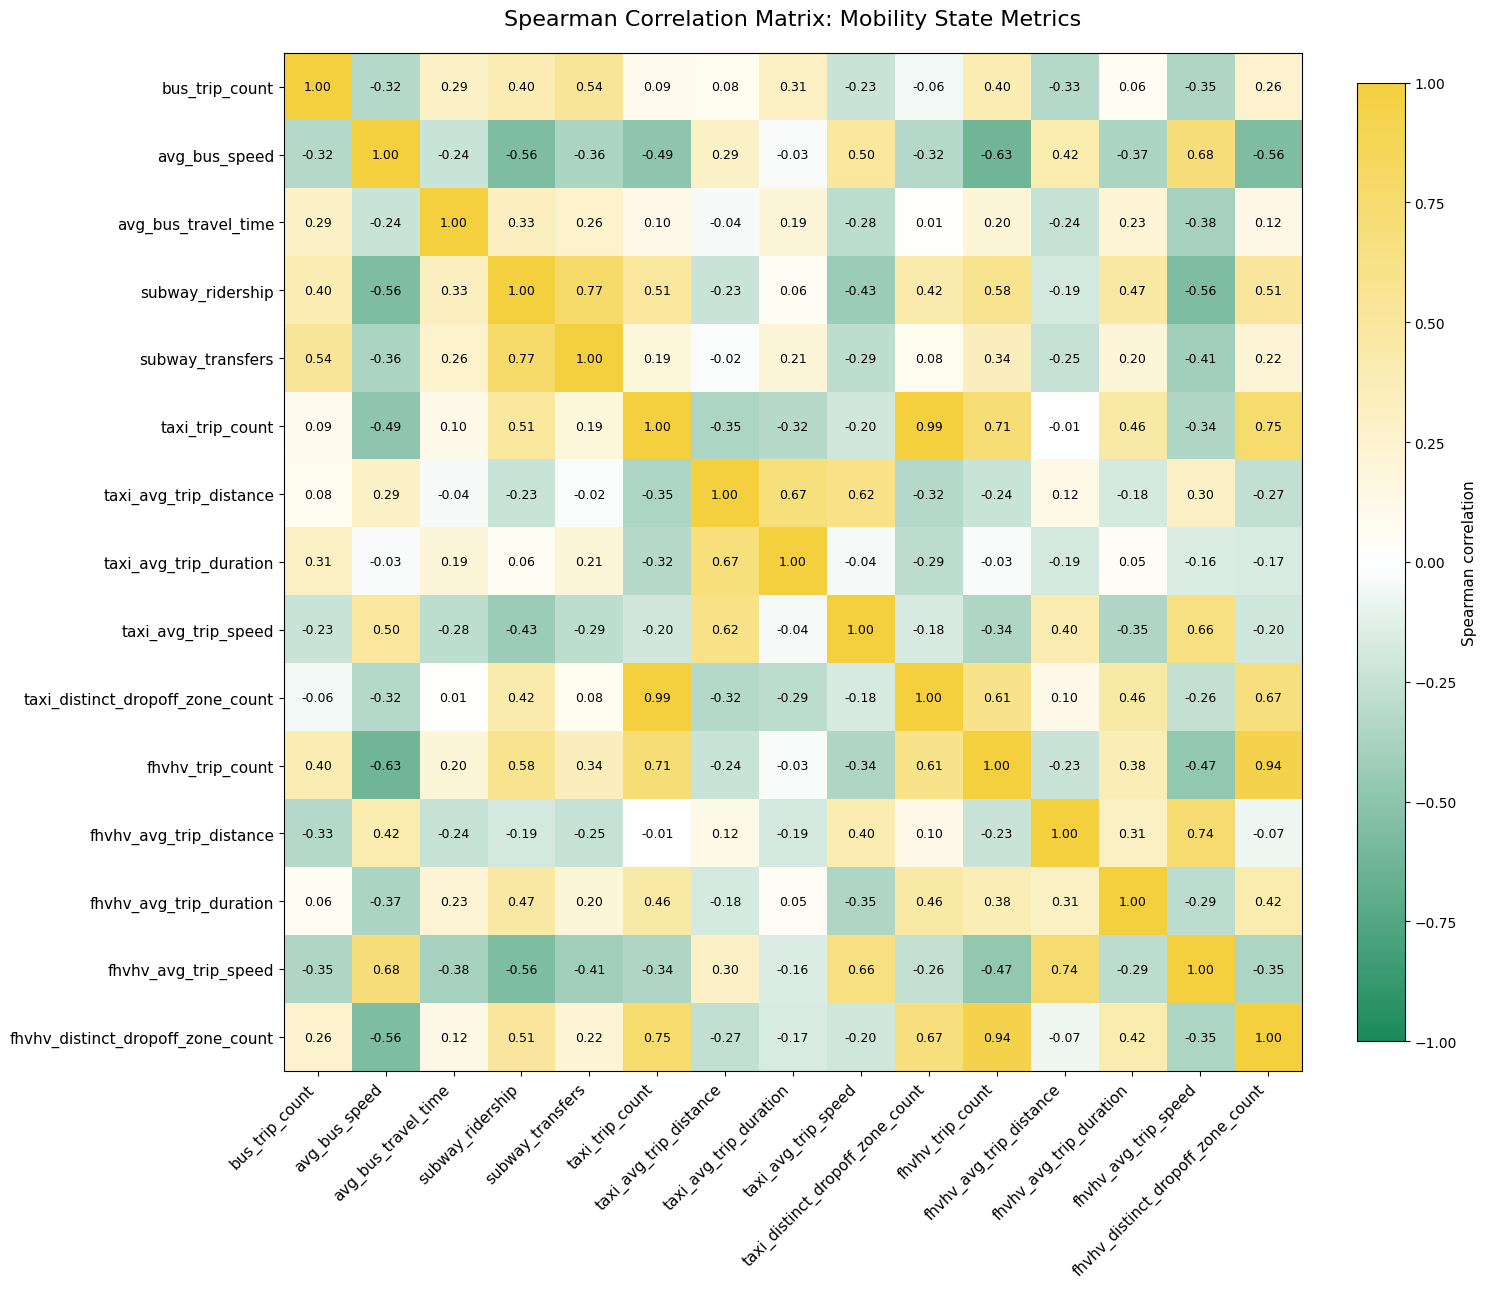

In [35]:
# -------------------------------------------------------------------
# Visualize mobility state metric correlations
# -------------------------------------------------------------------

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

correlation_matrix = candidate_interaction_correlation_df.copy()

heatmap_cmap = LinearSegmentedColormap.from_list(
    "green_white_yellow",
    ["#1b8a5a", "#ffffff", "#f4d03f"]
)

fig, ax = plt.subplots(figsize=(16, 13))

im = ax.imshow(
    correlation_matrix,
    cmap=heatmap_cmap,
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_yticks(range(len(correlation_matrix.index)))

ax.set_xticklabels(
    correlation_matrix.columns,
    rotation=45,
    ha="right",
    fontsize=11
)

ax.set_yticklabels(
    correlation_matrix.index,
    fontsize=11
)

for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        value = correlation_matrix.iloc[i, j]
        text_color = "black"

        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=9,
            color=text_color
        )

ax.set_title(
    "Spearman Correlation Matrix: Mobility State Metrics",
    fontsize=16,
    pad=20
)

cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.035,
    pad=0.04
)

cbar.ax.tick_params(labelsize=10)
cbar.set_label("Spearman correlation", fontsize=11)

plt.tight_layout()
plt.show()

Findings\. The mobility\-state metrics exhibit varying degrees of correlation, indicating that they capture multiple dimensions of transportation activity rather than a single underlying mobility signal\. Several highly correlated pairs were identified, including Subway ridership and Subway transfers \(0\.77\), Taxi trip count and Taxi distinct dropoff\-zone count \(0\.99\), and FHVHV trip count and FHVHV distinct dropoff\-zone count \(0\.94\)\. These relationships suggest that some metrics provide largely redundant information, while others contribute unique signals related to demand, speed, distance, duration, and network utilization\. Based on these results, a smaller set of core mobility\-state metrics was selected for standardization and downstream interaction feature engineering, while highly redundant measures were excluded\.

### Standardized Mobility State Metrics

After reviewing coverage, distributions, and correlations, we create standardized mobility\-state features for the core metrics selected for downstream interaction engineering\. These z\-score features place demand and speed measures on a common scale, making it easier for downstream clustering, anomaly detection, and interaction features to compare mobility signals across transportation systems\.

In [36]:
selected_mobility_state_metrics = [
    "bus_trip_count",
    "avg_bus_speed",

    "subway_ridership",

    "taxi_trip_count",
    "taxi_avg_trip_speed",

    "fhvhv_trip_count",
    "fhvhv_avg_trip_speed",
]

In [37]:
# -------------------------------------------------------------------
# Create standardized mobility state metrics
# -------------------------------------------------------------------

standardized_mobility_state_feature_cols = []
standardized_mobility_state_summary_records = []

for metric in selected_mobility_state_metrics:

    feature_name = f"{metric}_zscore"

    metric_mean = spatial_panel_df[metric].mean(skipna=True)
    metric_std = spatial_panel_df[metric].std(skipna=True)

    spatial_panel_df[feature_name] = (
        spatial_panel_df[metric] - metric_mean
    ) / metric_std

    standardized_mobility_state_feature_cols.append(feature_name)

    standardized_mobility_state_summary_records.append({
        "source_metric": metric,
        "standardized_feature": feature_name,
        "mean": metric_mean,
        "std": metric_std,
        "non_null_observations": spatial_panel_df[feature_name].notna().sum(),
        "missing_observations": spatial_panel_df[feature_name].isna().sum(),
    })

standardized_mobility_state_summary_df = pd.DataFrame(
    standardized_mobility_state_summary_records
)

float_cols = standardized_mobility_state_summary_df.select_dtypes(
    include=["float"]
).columns

standardized_mobility_state_summary_df[float_cols] = (
    standardized_mobility_state_summary_df[float_cols].round(3)
)

display(standardized_mobility_state_summary_df)

,source_metric,standardized_feature,mean,std,non_null_observations,missing_observations
0,bus_trip_count,bus_trip_count_zscore,816.513,914.778,1476478,83112
1,avg_bus_speed,avg_bus_speed_zscore,9.394,3.390,1476478,83112
2,subway_ridership,subway_ridership_zscore,4308.209,7029.252,925080,634510
3,taxi_trip_count,taxi_trip_count_zscore,89.176,250.435,1559590,0
4,taxi_avg_trip_speed,taxi_avg_trip_speed_zscore,13.381,6.619,1125143,434447
5,fhvhv_trip_count,fhvhv_trip_count_zscore,499.034,523.865,1559590,0
6,fhvhv_avg_trip_speed,fhvhv_avg_trip_speed_zscore,14.810,4.649,1559590,0


Findings\. The selected mobility\-state metrics were successfully standardized onto a common scale, creating a consistent foundation for comparing and combining mobility signals across transportation systems\.

This validation confirms that the standardized mobility\-state features were created correctly and are centered on a common scale before being used in downstream interaction features\.

In [38]:
# -------------------------------------------------------------------
# QA: Confirm standardized mobility state features
# -------------------------------------------------------------------

zscore_validation_df = (
    spatial_panel_df[standardized_mobility_state_feature_cols]
    .agg(["mean", "std"])
    .T
    .reset_index()
    .rename(columns={"index": "feature"})
)

zscore_validation_df[["mean", "std"]] = (
    zscore_validation_df[["mean", "std"]].round(3)
)

display(zscore_validation_df)

,feature,mean,std
0,bus_trip_count_zscore,-0.0,1.0
1,avg_bus_speed_zscore,0.0,1.0
2,subway_ridership_zscore,0.0,1.0
3,taxi_trip_count_zscore,0.0,1.0
4,taxi_avg_trip_speed_zscore,0.0,1.0
5,fhvhv_trip_count_zscore,-0.0,1.0
6,fhvhv_avg_trip_speed_zscore,-0.0,1.0


Findings\. All standardized mobility\-state features were successfully normalized, with means of approximately 0 and standard deviations of 1 as expected\.

### Construct Demand Interaction Features

Demand interaction features are designed to capture how different transportation systems behave relative to one another within the same Taxi Zone and temporal bucket\. By combining standardized demand metrics across Taxi, FHVHV, Bus, and Subway systems, these features can identify mobility states where multiple modes simultaneously experience unusually high or low activity, potentially revealing patterns that are not visible when examining each transportation system independently\.

In [39]:
# -------------------------------------------------------------------
# Construct demand interaction features
# -------------------------------------------------------------------

demand_interaction_specs = [
    {
        "feature_name": "taxi_x_fhvhv_demand_zscore",
        "metric_a": "taxi_trip_count_zscore",
        "metric_b": "fhvhv_trip_count_zscore",
    },
    {
        "feature_name": "taxi_x_bus_demand_zscore",
        "metric_a": "taxi_trip_count_zscore",
        "metric_b": "bus_trip_count_zscore",
    },
    {
        "feature_name": "taxi_x_subway_demand_zscore",
        "metric_a": "taxi_trip_count_zscore",
        "metric_b": "subway_ridership_zscore",
    },
    {
        "feature_name": "fhvhv_x_bus_demand_zscore",
        "metric_a": "fhvhv_trip_count_zscore",
        "metric_b": "bus_trip_count_zscore",
    },
    {
        "feature_name": "fhvhv_x_subway_demand_zscore",
        "metric_a": "fhvhv_trip_count_zscore",
        "metric_b": "subway_ridership_zscore",
    },
    {
        "feature_name": "bus_x_subway_demand_zscore",
        "metric_a": "bus_trip_count_zscore",
        "metric_b": "subway_ridership_zscore",
    },
]

demand_interaction_feature_cols = []

for spec in demand_interaction_specs:

    feature_name = spec["feature_name"]
    metric_a = spec["metric_a"]
    metric_b = spec["metric_b"]

    spatial_panel_df[feature_name] = (
        spatial_panel_df[metric_a]
        * spatial_panel_df[metric_b]
    )

    demand_interaction_feature_cols.append(feature_name)

demand_interaction_summary_df = (
    spatial_panel_df[demand_interaction_feature_cols]
    .describe()
    .T
    .reset_index()
    .rename(columns={"index": "feature"})
)

float_cols = demand_interaction_summary_df.select_dtypes(include=["float"]).columns
demand_interaction_summary_df[float_cols] = (
    demand_interaction_summary_df[float_cols].round(3)
)

display(demand_interaction_summary_df)

,feature,count,mean,std,min,25%,50%,75%,max
0,taxi_x_fhvhv_demand_zscore,1559590.0,0.622,3.098,-2.724,0.001,0.159,0.292,158.940
1,taxi_x_bus_demand_zscore,1476478.0,0.006,0.785,-7.589,-0.147,0.050,0.184,28.999
2,taxi_x_subway_demand_zscore,925080.0,0.581,3.229,-5.693,0.001,0.127,0.191,87.733
3,fhvhv_x_bus_demand_zscore,1476478.0,0.237,1.202,-10.000,-0.052,0.115,0.408,45.740
4,fhvhv_x_subway_demand_zscore,925080.0,0.401,1.737,-5.420,-0.033,0.109,0.344,60.575
5,bus_x_subway_demand_zscore,912676.0,0.214,1.605,-8.630,-0.036,0.106,0.299,56.220


Findings\. The demand interaction features exhibit substantial variation across Taxi Zones and time periods, indicating that mobility systems do not always move together\. While most observations are clustered near zero, the presence of both large positive and negative values suggests that these features successfully capture periods where transportation modes simultaneously experience unusually high demand, unusually low demand, or divergent demand patterns across systems\.

### Construct Speed / Congestion Interaction Features

Speed interaction features are designed to capture shared congestion conditions across transportation systems\. By combining standardized speed metrics, these features can identify periods where roadway\-based transportation modes simultaneously experience unusually fast or unusually slow movement, potentially revealing broader mobility conditions that are not visible from individual speed measures alone\.

In [40]:
# -------------------------------------------------------------------
# Construct speed / congestion interaction features
# -------------------------------------------------------------------

speed_interaction_specs = [
    {
        "feature_name": "taxi_x_fhvhv_speed_zscore",
        "metric_a": "taxi_avg_trip_speed_zscore",
        "metric_b": "fhvhv_avg_trip_speed_zscore",
    },
    {
        "feature_name": "taxi_x_bus_speed_zscore",
        "metric_a": "taxi_avg_trip_speed_zscore",
        "metric_b": "avg_bus_speed_zscore",
    },
    {
        "feature_name": "fhvhv_x_bus_speed_zscore",
        "metric_a": "fhvhv_avg_trip_speed_zscore",
        "metric_b": "avg_bus_speed_zscore",
    },
]

speed_interaction_feature_cols = []

for spec in speed_interaction_specs:

    feature_name = spec["feature_name"]
    metric_a = spec["metric_a"]
    metric_b = spec["metric_b"]

    spatial_panel_df[feature_name] = (
        spatial_panel_df[metric_a]
        * spatial_panel_df[metric_b]
    )

    speed_interaction_feature_cols.append(feature_name)

speed_interaction_summary_df = (
    spatial_panel_df[speed_interaction_feature_cols]
    .describe()
    .T
    .reset_index()
    .rename(columns={"index": "feature"})
)

float_cols = speed_interaction_summary_df.select_dtypes(include=["float"]).columns
speed_interaction_summary_df[float_cols] = (
    speed_interaction_summary_df[float_cols].round(3)
)

display(speed_interaction_summary_df)

,feature,count,mean,std,min,25%,50%,75%,max
0,taxi_x_fhvhv_speed_zscore,1125143.0,0.467,1.113,-41.689,0.007,0.212,0.664,48.800
1,taxi_x_bus_speed_zscore,1081531.0,0.310,0.829,-15.110,-0.023,0.147,0.537,33.724
2,fhvhv_x_bus_speed_zscore,1476478.0,0.439,1.678,-27.116,0.008,0.236,0.733,45.051


Findings\. The speed interaction features exhibit a wide range of positive and negative values, indicating that roadway transportation modes do not always experience congestion conditions uniformly\. Most observations are concentrated near zero, while larger positive values identify periods when multiple transportation systems simultaneously experienced unusually fast or unusually slow movement\. These features provide a compact representation of shared congestion conditions across Taxi, FHVHV, and Bus networks\.

### Construct Transit\-to\-Roadway Shift Features

Transit\-to\-roadway shift features compare transit activity against roadway\-based mobility demand within the same Taxi Zone and temporal bucket\. Unlike the z\-score interaction features above, these ratio\-style measures are more directly interpretable: higher values suggest stronger transit activity relative to Taxi or FHVHV demand, while lower values suggest mobility activity is more roadway\-heavy\.

In [41]:
# -------------------------------------------------------------------
# Construct transit-to-roadway shift features
# -------------------------------------------------------------------

transit_roadway_shift_specs = [
    {
        "feature_name": "subway_to_taxi_demand_shift_ratio",
        "numerator": "subway_ridership",
        "denominator": "taxi_trip_count",
    },
    {
        "feature_name": "subway_to_fhvhv_demand_shift_ratio",
        "numerator": "subway_ridership",
        "denominator": "fhvhv_trip_count",
    },
    {
        "feature_name": "bus_to_taxi_demand_shift_ratio",
        "numerator": "bus_trip_count",
        "denominator": "taxi_trip_count",
    },
    {
        "feature_name": "bus_to_fhvhv_demand_shift_ratio",
        "numerator": "bus_trip_count",
        "denominator": "fhvhv_trip_count",
    },
]

transit_roadway_shift_feature_cols = []

for spec in transit_roadway_shift_specs:

    feature_name = spec["feature_name"]
    numerator = spec["numerator"]
    denominator = spec["denominator"]

    spatial_panel_df[feature_name] = (
        np.log1p(spatial_panel_df[numerator])
        - np.log1p(spatial_panel_df[denominator])
    )

    transit_roadway_shift_feature_cols.append(feature_name)

transit_roadway_shift_summary_df = (
    spatial_panel_df[transit_roadway_shift_feature_cols]
    .describe()
    .T
    .reset_index()
    .rename(columns={"index": "feature"})
)

float_cols = transit_roadway_shift_summary_df.select_dtypes(include=["float"]).columns
transit_roadway_shift_summary_df[float_cols] = (
    transit_roadway_shift_summary_df[float_cols].round(3)
)

display(transit_roadway_shift_summary_df)

,feature,count,mean,std,min,25%,50%,75%,max
0,subway_to_taxi_demand_shift_ratio,925080.0,4.619,2.174,-7.724,3.404,4.942,6.109,9.925
1,subway_to_fhvhv_demand_shift_ratio,925080.0,1.144,1.567,-8.280,0.523,1.332,2.074,8.327
2,bus_to_taxi_demand_shift_ratio,1476478.0,4.141,2.286,-3.873,2.856,4.760,5.846,8.822
3,bus_to_fhvhv_demand_shift_ratio,1476478.0,0.585,1.333,-5.535,-0.169,0.579,1.285,6.899


Findings\. The transit\-to\-roadway shift features indicate substantial variation in the relative balance between transit and roadway activity across Taxi Zones and time periods\. Subway activity generally exceeds Taxi demand by a larger margin than FHVHV demand, while Bus activity exhibits a similar pattern\. The wide range of observed values suggests that these features successfully capture meaningful differences in modal preference and transportation\-system utilization throughout the city\.

🔍 Why We Use Log Ratios Instead of Z\-Scores\. Unlike the demand and speed interaction features, the objective of these features is to measure the relative balance between transportation modes rather than whether activity levels are unusually high or low\. A z\-score interaction answers questions such as "Are Subway and Taxi demand simultaneously above normal?" In contrast, these shift features answer questions such as "Is mobility activity more transit\-oriented or roadway\-oriented?" Log\-transformed ratios preserve that interpretation while avoiding the instability that can occur when raw Taxi or FHVHV trip counts are very small\.

### Validate Interaction Features

The final step validates that the newly engineered multimodal interaction features are usable for downstream modeling\. We check feature population, missingness, infinite values, and basic distribution ranges so we can confirm that the interaction layer did not introduce unstable or unusable columns\.

In [42]:
# -------------------------------------------------------------------
# Validate multimodal interaction features
# -------------------------------------------------------------------

multimodal_interaction_feature_cols = (
    standardized_mobility_state_feature_cols
    + demand_interaction_feature_cols
    + speed_interaction_feature_cols
    + transit_roadway_shift_feature_cols
)

interaction_feature_validation_records = []

for feature in multimodal_interaction_feature_cols:

    interaction_feature_validation_records.append({
        "feature": feature,
        "non_null_observations": spatial_panel_df[feature].notna().sum(),
        "missing_observations": spatial_panel_df[feature].isna().sum(),
        "non_null_pct": spatial_panel_df[feature].notna().mean(),
        "infinite_values": np.isinf(spatial_panel_df[feature]).sum(),
        "min": spatial_panel_df[feature].min(skipna=True),
        "max": spatial_panel_df[feature].max(skipna=True),
    })

interaction_feature_validation_df = pd.DataFrame(
    interaction_feature_validation_records
)

float_cols = interaction_feature_validation_df.select_dtypes(include=["float"]).columns
interaction_feature_validation_df[float_cols] = (
    interaction_feature_validation_df[float_cols].round(3)
)

display(interaction_feature_validation_df)

,feature,non_null_observations,missing_observations,non_null_pct,infinite_values,min,max
0,bus_trip_count_zscore,1476478,83112,0.947,0,-0.891,18.337
1,avg_bus_speed_zscore,1476478,83112,0.947,0,-2.195,8.512
2,subway_ridership_zscore,925080,634510,0.593,0,-0.613,15.707
3,taxi_trip_count_zscore,1559590,0,1.000,0,-0.356,13.520
4,taxi_avg_trip_speed_zscore,1125143,434447,0.721,0,-2.022,13.087
5,fhvhv_trip_count_zscore,1559590,0,1.000,0,-0.953,15.569
6,fhvhv_avg_trip_speed_zscore,1559590,0,1.000,0,-3.186,10.762
7,taxi_x_fhvhv_demand_zscore,1559590,0,1.000,0,-2.724,158.940
8,taxi_x_bus_demand_zscore,1476478,83112,0.947,0,-7.589,28.999
9,taxi_x_subway_demand_zscore,925080,634510,0.593,0,-5.693,87.733


Findings\. The multimodal interaction features passed QA and behaved as expected\. Coverage reflects the underlying mobility systems used to build them, no invalid values were introduced, and the features exhibit substantial variation across Taxi Zones and time periods\. These features should provide useful signals around multimodal demand patterns, congestion conditions, and shifts between transit and roadway activity\.

### Section Summary

In this section we moved beyond individual mobility systems and engineered features that capture how transportation modes interact with one another\. We identified a core set of mobility\-state metrics, standardized them onto a common scale, created demand and congestion interaction features, and constructed transit\-to\-roadway shift measures\. Together, these features provide a richer view of multimodal mobility behavior and may help identify patterns that are not visible when analyzing each transportation system independently\.

## 1\.5\.3\.4 Local vs Connected\-Zone Interaction Features

In the previous section, we selected a compact set of core mobility\-state metrics and standardized them so demand and speed measures could be compared on a common scale\. This section extends that same logic spatially by comparing each Taxi Zone’s local mobility conditions against the average conditions in its connected neighboring zones\. The goal is to identify localized mobility divergence: zones that are unusually busy, unusually slow, or otherwise behaving differently from the connected areas around them\.

💡 Note: These divergence features build upon, rather than replace, the connected\-zone spillover features created in Section 1\.5\.2\. The spillover features describe mobility conditions in the surrounding connected zones \(e\.g\., average neighboring Taxi demand or Subway ridership\), providing geographic context for each Taxi Zone\. The divergence features introduced here measure the difference between local conditions and those surrounding conditions\. As a result, spillover features answer "What is happening around this zone?" while divergence features answer "Is this zone behaving differently than the areas around it?" Together, the two feature families provide both neighborhood context and localized anomaly signals\.

### Construct Local vs Connected\-Zone Divergence Features

The metrics used here are the same core mobility\-state metrics selected in 1\.5\.3\.3: Bus trip count and speed, Subway ridership, Taxi trip count and speed, and FHVHV trip count and speed\. These metrics already showed useful variation, from sparse Traffic coverage to complete Taxi/FHVHV coverage, and the cleaned speed distributions now look reasonable, with Taxi average trip speed capped at 100 mph and FHVHV average trip speed topping out around 65 mph\. We now compare each local standardized metric to its connected\-zone standardized counterpart\.

In [43]:
# -------------------------------------------------------------------
# Construct local vs connected-zone divergence features
# -------------------------------------------------------------------

local_connected_metric_pairs = [
    {
        "local_metric": "bus_trip_count",
        "connected_metric": "connected_mean_bus_trip_count",
        "feature_name": "bus_trip_count_local_vs_connected_zscore",
    },
    {
        "local_metric": "avg_bus_speed",
        "connected_metric": "connected_mean_avg_bus_speed",
        "feature_name": "avg_bus_speed_local_vs_connected_zscore",
    },
    {
        "local_metric": "subway_ridership",
        "connected_metric": "connected_mean_subway_ridership",
        "feature_name": "subway_ridership_local_vs_connected_zscore",
    },
    {
        "local_metric": "taxi_trip_count",
        "connected_metric": "connected_mean_taxi_trip_count",
        "feature_name": "taxi_trip_count_local_vs_connected_zscore",
    },
    {
        "local_metric": "taxi_avg_trip_speed",
        "connected_metric": "connected_mean_taxi_avg_trip_speed",
        "feature_name": "taxi_avg_trip_speed_local_vs_connected_zscore",
    },
    {
        "local_metric": "fhvhv_trip_count",
        "connected_metric": "connected_mean_fhvhv_trip_count",
        "feature_name": "fhvhv_trip_count_local_vs_connected_zscore",
    },
    {
        "local_metric": "fhvhv_avg_trip_speed",
        "connected_metric": "connected_mean_fhvhv_avg_trip_speed",
        "feature_name": "fhvhv_avg_trip_speed_local_vs_connected_zscore",
    },
]

local_connected_divergence_feature_cols = []
local_connected_summary_records = []

for spec in local_connected_metric_pairs:

    local_metric = spec["local_metric"]
    connected_metric = spec["connected_metric"]
    feature_name = spec["feature_name"]

    local_zscore_col = f"{local_metric}_zscore"
    connected_zscore_col = f"{connected_metric}_zscore"

    connected_mean = spatial_panel_df[connected_metric].mean(skipna=True)
    connected_std = spatial_panel_df[connected_metric].std(skipna=True)

    spatial_panel_df[connected_zscore_col] = (
        spatial_panel_df[connected_metric] - connected_mean
    ) / connected_std

    spatial_panel_df[feature_name] = (
        spatial_panel_df[local_zscore_col]
        - spatial_panel_df[connected_zscore_col]
    )

    local_connected_divergence_feature_cols.append(feature_name)

    local_connected_summary_records.append({
        "local_metric": local_metric,
        "connected_metric": connected_metric,
        "connected_zscore_feature": connected_zscore_col,
        "divergence_feature": feature_name,
        "non_null_observations": spatial_panel_df[feature_name].notna().sum(),
        "missing_observations": spatial_panel_df[feature_name].isna().sum(),
        "mean": spatial_panel_df[feature_name].mean(skipna=True),
        "std": spatial_panel_df[feature_name].std(skipna=True),
        "min": spatial_panel_df[feature_name].min(skipna=True),
        "max": spatial_panel_df[feature_name].max(skipna=True),
    })

local_connected_divergence_summary_df = pd.DataFrame(
    local_connected_summary_records
)

float_cols = local_connected_divergence_summary_df.select_dtypes(
    include=["float"]
).columns

local_connected_divergence_summary_df[float_cols] = (
    local_connected_divergence_summary_df[float_cols].round(3)
)

display(local_connected_divergence_summary_df)

,local_metric,connected_metric,connected_zscore_feature,divergence_feature,non_null_observations,missing_observations,mean,std,min,max
0,bus_trip_count,connected_mean_bus_trip_count,connected_mean_bus_trip_count_zscore,bus_trip_count_local_vs_connected_zscore,1464618,94972,-0.013,1.099,-9.483,16.635
1,avg_bus_speed,connected_mean_avg_bus_speed,connected_mean_avg_bus_speed_zscore,avg_bus_speed_local_vs_connected_zscore,1464618,94972,0.004,0.789,-4.719,7.629
2,subway_ridership,connected_mean_subway_ridership,connected_mean_subway_ridership_zscore,subway_ridership_local_vs_connected_zscore,871710,687880,-0.066,1.106,-12.337,13.300
3,taxi_trip_count,connected_mean_taxi_trip_count,connected_mean_taxi_trip_count_zscore,taxi_trip_count_local_vs_connected_zscore,1541800,17790,0.003,0.735,-10.303,9.925
4,taxi_avg_trip_speed,connected_mean_taxi_avg_trip_speed,connected_mean_taxi_avg_trip_speed_zscore,taxi_avg_trip_speed_local_vs_connected_zscore,1066517,493073,0.055,0.897,-14.099,13.730
5,fhvhv_trip_count,connected_mean_fhvhv_trip_count,connected_mean_fhvhv_trip_count_zscore,fhvhv_trip_count_local_vs_connected_zscore,1541800,17790,0.011,1.068,-15.901,14.000
6,fhvhv_avg_trip_speed,connected_mean_fhvhv_avg_trip_speed,connected_mean_fhvhv_avg_trip_speed_zscore,fhvhv_avg_trip_speed_local_vs_connected_zscore,1541800,17790,0.021,0.860,-10.956,11.180


Findings\. These features behaved as expected\. Most Taxi Zones look fairly similar to their connected neighbors most of the time, but there are plenty of periods where local demand or mobility conditions diverge noticeably from surrounding areas\. Those larger positive and negative values are exactly the localized mobility patterns these features were designed to capture\.

### Validate Local vs Connected\-Zone Features

This final QA step confirms that the divergence features were created successfully and contain valid modeling\-ready values\. We verify coverage, missingness, numeric data types, and the absence of infinite values before incorporating these features into the final feature panel\.

In [44]:
# -------------------------------------------------------------------
# Validate local vs connected-zone divergence features
# -------------------------------------------------------------------

local_connected_validation_records = []

for feature in local_connected_divergence_feature_cols:

    local_connected_validation_records.append({
        "feature": feature,
        "non_null_observations": spatial_panel_df[feature].notna().sum(),
        "missing_observations": spatial_panel_df[feature].isna().sum(),
        "non_null_pct": spatial_panel_df[feature].notna().mean(),
        "infinite_values": np.isinf(spatial_panel_df[feature]).sum(),
        "min": spatial_panel_df[feature].min(skipna=True),
        "max": spatial_panel_df[feature].max(skipna=True),
    })

local_connected_validation_df = pd.DataFrame(
    local_connected_validation_records
)

float_cols = local_connected_validation_df.select_dtypes(
    include=["float"]
).columns

local_connected_validation_df[float_cols] = (
    local_connected_validation_df[float_cols].round(3)
)

# -------------------------------------------------------------------
# Assert local vs connected-zone divergence feature validity
# -------------------------------------------------------------------

assert local_connected_validation_df["infinite_values"].sum() == 0, (
    "One or more local vs connected-zone divergence features contain infinite values."
)

print("Local vs connected-zone feature validation passed.")

display(local_connected_validation_df)

Local vs connected-zone feature validation passed.


,feature,non_null_observations,missing_observations,non_null_pct,infinite_values,min,max
0,bus_trip_count_local_vs_connected_zscore,1464618,94972,0.939,0,-9.483,16.635
1,avg_bus_speed_local_vs_connected_zscore,1464618,94972,0.939,0,-4.719,7.629
2,subway_ridership_local_vs_connected_zscore,871710,687880,0.559,0,-12.337,13.300
3,taxi_trip_count_local_vs_connected_zscore,1541800,17790,0.989,0,-10.303,9.925
4,taxi_avg_trip_speed_local_vs_connected_zscore,1066517,493073,0.684,0,-14.099,13.730
5,fhvhv_trip_count_local_vs_connected_zscore,1541800,17790,0.989,0,-15.901,14.000
6,fhvhv_avg_trip_speed_local_vs_connected_zscore,1541800,17790,0.989,0,-10.956,11.180


Findings\. The local\-versus\-connected\-zone divergence features passed QA and behaved as expected\. Coverage reflects the underlying mobility systems used to construct the features, no invalid values were introduced, and the features exhibit substantial variation across Taxi Zones and time periods\. These features should provide useful signals around localized mobility conditions that differ from those observed in surrounding connected zones\.

### Section Summary

This section adds a simple but useful question: does this zone look different from the areas around it? The connected\-zone features from 1\.5\.2 tell us what is happening nearby; these new divergence features tell us whether the local zone is unusually high, low, fast, or slow compared with those nearby zones\.

## 1\.5\.3\.5 Bridge/Tunnel vs Local Mobility Interaction Features

This section connects bridge and tunnel activity to local mobility conditions\. The goal is to capture whether zones with Manhattan\-facing crossing activity also show unusual Taxi, FHVHV, Subway, or speed patterns in the local mobility panel\.

### Construct Bridge/Tunnel Mobility Interaction Features

Rather than creating every possible bridge/tunnel interaction, we focus on a few policy\-relevant relationships between Manhattan\-connected crossing share and the core local mobility\-state metrics\.

In [45]:
# -------------------------------------------------------------------
# Construct Bridge/Tunnel mobility interaction features
# -------------------------------------------------------------------

bridge_tunnel_context_metric = "manhattan_connected_crossing_share"

bridge_tunnel_mobility_metrics = [
    "bus_trip_count_zscore",
    "avg_bus_speed_zscore",
    "subway_ridership_zscore",
    "taxi_trip_count_zscore",
    "taxi_avg_trip_speed_zscore",
    "fhvhv_trip_count_zscore",
    "fhvhv_avg_trip_speed_zscore",
]

bridge_tunnel_interaction_feature_cols = []

for mobility_metric in bridge_tunnel_mobility_metrics:

    source_metric = mobility_metric.replace("_zscore", "")

    feature_name = (
        f"mta_crossing_share_x_{source_metric}_zscore"
    )

    spatial_panel_df[feature_name] = (
        spatial_panel_df[bridge_tunnel_context_metric]
        * spatial_panel_df[mobility_metric]
    )

    bridge_tunnel_interaction_feature_cols.append(feature_name)

bridge_tunnel_interaction_summary_df = (
    spatial_panel_df[bridge_tunnel_interaction_feature_cols]
    .describe()
    .T
    .reset_index()
    .rename(columns={"index": "feature"})
)

float_cols = bridge_tunnel_interaction_summary_df.select_dtypes(
    include=["float"]
).columns

bridge_tunnel_interaction_summary_df[float_cols] = (
    bridge_tunnel_interaction_summary_df[float_cols].round(3)
)

display(bridge_tunnel_interaction_summary_df)

,feature,count,mean,std,min,25%,50%,75%,max
0,mta_crossing_share_x_bus_trip_count_zscore,1476478.0,0.008,0.439,-0.469,-0.240,-0.114,0.118,8.752
1,mta_crossing_share_x_avg_bus_speed_zscore,1476478.0,-0.009,0.427,-1.003,-0.305,-0.082,0.182,3.601
2,mta_crossing_share_x_subway_ridership_zscore,925080.0,0.009,0.440,-0.332,-0.210,-0.147,0.049,7.160
3,mta_crossing_share_x_taxi_trip_count_zscore,1559590.0,0.005,0.443,-0.193,-0.154,-0.139,-0.105,6.096
4,mta_crossing_share_x_taxi_avg_trip_speed_zscore,1125143.0,-0.011,0.418,-1.092,-0.270,-0.074,0.170,6.046
5,mta_crossing_share_x_fhvhv_trip_count_zscore,1559590.0,0.008,0.435,-0.515,-0.280,-0.122,0.163,8.142
6,mta_crossing_share_x_fhvhv_avg_trip_speed_zscore,1559590.0,-0.015,0.416,-1.723,-0.280,-0.031,0.248,4.606


Findings\. The Bridge/Tunnel interaction features behaved as expected\. Because Manhattan\-connected crossing share is bounded between 0 and 1, the resulting interaction features remain well\-scaled and centered near zero, while still capturing periods when local mobility conditions coincide with unusually high or low Manhattan\-oriented crossing activity\. The presence of larger positive values across all modes indicates that these features successfully identify periods when elevated local mobility activity aligns with higher levels of Manhattan\-connected bridge and tunnel traffic\.

### Validate Bridge/Tunnel Interaction Features

This QA confirms that the Bridge/Tunnel interaction features were created cleanly and are safe to carry into the final feature panel\.

In [46]:
# -------------------------------------------------------------------
# Validate Bridge/Tunnel mobility interaction features
# -------------------------------------------------------------------

bridge_tunnel_interaction_validation_records = []

for feature in bridge_tunnel_interaction_feature_cols:

    bridge_tunnel_interaction_validation_records.append({
        "feature": feature,
        "non_null_observations": spatial_panel_df[feature].notna().sum(),
        "missing_observations": spatial_panel_df[feature].isna().sum(),
        "non_null_pct": spatial_panel_df[feature].notna().mean(),
        "infinite_values": np.isinf(spatial_panel_df[feature]).sum(),
        "min": spatial_panel_df[feature].min(skipna=True),
        "max": spatial_panel_df[feature].max(skipna=True),
    })

bridge_tunnel_interaction_validation_df = pd.DataFrame(
    bridge_tunnel_interaction_validation_records
)

float_cols = bridge_tunnel_interaction_validation_df.select_dtypes(
    include=["float"]
).columns

bridge_tunnel_interaction_validation_df[float_cols] = (
    bridge_tunnel_interaction_validation_df[float_cols].round(3)
)

display(bridge_tunnel_interaction_validation_df)

,feature,non_null_observations,missing_observations,non_null_pct,infinite_values,min,max
0,mta_crossing_share_x_bus_trip_count_zscore,1476478,83112,0.947,0,-0.469,8.752
1,mta_crossing_share_x_avg_bus_speed_zscore,1476478,83112,0.947,0,-1.003,3.601
2,mta_crossing_share_x_subway_ridership_zscore,925080,634510,0.593,0,-0.332,7.160
3,mta_crossing_share_x_taxi_trip_count_zscore,1559590,0,1.000,0,-0.193,6.096
4,mta_crossing_share_x_taxi_avg_trip_speed_zscore,1125143,434447,0.721,0,-1.092,6.046
5,mta_crossing_share_x_fhvhv_trip_count_zscore,1559590,0,1.000,0,-0.515,8.142
6,mta_crossing_share_x_fhvhv_avg_trip_speed_zscore,1559590,0,1.000,0,-1.723,4.606


Findings\. The Bridge/Tunnel interaction features passed QA and behaved as expected\. Coverage reflects the underlying mobility systems used to construct the features, no invalid values were introduced, and the resulting feature values remain stable and well\-scaled\. These features should help identify periods when local mobility conditions align with unusually high levels of Manhattan\-connected bridge and tunnel activity\.

## 1\.5\.3\.6 QA and Feature Manifest

This final section wraps the notebook by confirming what we created, validating the final interaction feature set, and preparing the feature manifest/output artifacts for downstream modeling\.

### Validate Final Interaction Feature Set

This QA summarizes the feature families created in this notebook and confirms that the final interaction feature set is complete before we write outputs\.

In [47]:
# -------------------------------------------------------------------
# Validate final interaction feature set
# -------------------------------------------------------------------

interaction_feature_family_summary_df = pd.DataFrame({
    "feature_family": [
        "standardized_mobility_state_features",
        "demand_interaction_features",
        "speed_congestion_interaction_features",
        "transit_to_roadway_shift_features",
        "local_vs_connected_zone_divergence_features",
        "bridge_tunnel_interaction_features",
    ],
    "feature_count": [
        len(standardized_mobility_state_feature_cols),
        len(demand_interaction_feature_cols),
        len(speed_interaction_feature_cols),
        len(transit_roadway_shift_feature_cols),
        len(local_connected_divergence_feature_cols),
        len(bridge_tunnel_interaction_feature_cols),
    ],
})

interaction_feature_family_summary_df.loc[
    len(interaction_feature_family_summary_df)
] = {
    "feature_family": "total_interaction_features",
    "feature_count": interaction_feature_family_summary_df["feature_count"].sum(),
}

display(interaction_feature_family_summary_df)

final_interaction_feature_cols = (
    standardized_mobility_state_feature_cols
    + demand_interaction_feature_cols
    + speed_interaction_feature_cols
    + transit_roadway_shift_feature_cols
    + local_connected_divergence_feature_cols
    + bridge_tunnel_interaction_feature_cols
)

final_interaction_feature_validation_df = pd.DataFrame({
    "qa_check": [
        "expected_feature_count",
        "actual_feature_count",
        "missing_feature_columns",
        "duplicate_feature_columns",
    ],
    "value": [
        interaction_feature_family_summary_df.loc[
            interaction_feature_family_summary_df["feature_family"]
            == "total_interaction_features",
            "feature_count",
        ].iloc[0],
        len(final_interaction_feature_cols),
        len([
            col for col in final_interaction_feature_cols
            if col not in spatial_panel_df.columns
        ]),
        len(final_interaction_feature_cols) - len(set(final_interaction_feature_cols)),
    ],
})

display(final_interaction_feature_validation_df)

assert final_interaction_feature_validation_df.loc[
    final_interaction_feature_validation_df["qa_check"] == "missing_feature_columns",
    "value",
].iloc[0] == 0, "One or more final interaction feature columns are missing."

assert final_interaction_feature_validation_df.loc[
    final_interaction_feature_validation_df["qa_check"] == "duplicate_feature_columns",
    "value",
].iloc[0] == 0, "Duplicate interaction feature columns detected."

print("Final interaction feature set validation passed.")

,feature_family,feature_count
0,standardized_mobility_state_features,7
1,demand_interaction_features,6
2,speed_congestion_interaction_features,3
3,transit_to_roadway_shift_features,4
4,local_vs_connected_zone_divergence_features,7
5,bridge_tunnel_interaction_features,7
6,total_interaction_features,34


,qa_check,value
0,expected_feature_count,34
1,actual_feature_count,34
2,missing_feature_columns,0
3,duplicate_feature_columns,0


Final interaction feature set validation passed.


Findings\. The final interaction feature set is complete and clean\. We created 34 total features across six feature families, with no missing columns and no duplicate feature names\. This gives us a compact but useful interaction layer covering standardized mobility states, multimodal demand, speed/congestion, transit\-to\-roadway balance, local\-vs\-neighbor divergence, and Bridge/Tunnel interactions\.

### Update Feature Manifest

This step creates a feature manifest for the new interaction features, the Bridge/Tunnel context columns, and the Traffic temporal context fields joined or preserved in this notebook\. The manifest keeps the downstream lineage clean by recording each feature’s source metric, modality, feature type, and notebook source\.

In [48]:
# -------------------------------------------------------------------
# Update interaction feature manifest
# -------------------------------------------------------------------

DEMAND_SOURCE_METRIC_BY_MODE = {
    "traffic": "traffic_volume",
    "bus": "bus_trip_count",
    "subway": "subway_ridership",
    "taxi": "taxi_trip_count",
    "fhvhv": "fhvhv_trip_count",
}

SPEED_SOURCE_METRIC_BY_MODE = {
    "bus": "avg_bus_speed",
    "taxi": "taxi_avg_trip_speed",
    "fhvhv": "fhvhv_avg_trip_speed",
}

METRIC_MODALITY_PREFIXES = {
    "traffic": ["traffic_"],
    "bus": ["bus_", "avg_bus_"],
    "subway": ["subway_"],
    "taxi": ["taxi_"],
    "fhvhv": ["fhvhv_"],
}

BRIDGE_TUNNEL_CONTEXT_FEATURES = [
    "total_mta_crossing_volume",
    "manhattan_connected_mta_crossing_volume",
    "non_manhattan_connected_mta_crossing_volume",
    "manhattan_connected_crossing_share",
]

TRAFFIC_CONTEXT_FEATURES = {
    "max_yearly_ratio": {
        "source_metric": "traffic_volume",
        "feature_type": "traffic_temporal_coverage_ratio",
        "definition": "Traffic sensor coverage stability metric based on yearly observation balance.",
    },
    "is_reliable_traffic_temporal_zone": {
        "source_metric": "traffic_volume",
        "feature_type": "traffic_temporal_reliability_flag",
        "definition": "Flag indicating Traffic-monitored Taxi Zones with reliable enough longitudinal coverage for sparse temporal context.",
    },
    "is_stable_or_moderate_traffic_zone": {
        "source_metric": "traffic_volume",
        "feature_type": "traffic_temporal_stability_flag",
        "definition": "Flag indicating Traffic-monitored Taxi Zones with stable or moderate temporal coverage patterns.",
    },
}

interaction_feature_manifest_records = []


def composite_source_metric(metrics):
    """Store multi-metric feature lineage in one manifest field."""
    return "|".join(metrics)


def infer_metric_modality(source_metric):
    """Map a single source metric to its transportation system."""
    for modality, prefixes in METRIC_MODALITY_PREFIXES.items():
        if any(source_metric.startswith(prefix) for prefix in prefixes):
            return modality

    if source_metric in {"mta_crossing_volume", "manhattan_connected_crossing_share"}:
        return "traffic"

    return "other"


def mode_pair_from_x_feature(feature_name, suffix):
    """Parse mode_a_x_mode_b interaction feature names."""
    stem = feature_name.replace(suffix, "")
    return stem.split("_x_")


def mode_pair_from_ratio_feature(feature_name):
    """Parse mode_a_to_mode_b demand-shift ratio feature names."""
    stem = feature_name.replace("_demand_shift_ratio", "")
    return stem.split("_to_")


def add_interaction_feature_manifest_records(
    feature_cols,
    feature_type,
    source_metric_getter,
    modality_getter,
    definition_getter,
):
    for feature_col in feature_cols:
        source_metric = source_metric_getter(feature_col)

        interaction_feature_manifest_records.append(
            {
                "feature_name": feature_col,
                "source_metric": source_metric,
                "feature_family": "multimodal_interaction",
                "feature_type": feature_type,
                "feature_category": feature_type,
                "modality": modality_getter(feature_col, source_metric),
                "definition": definition_getter(feature_col, source_metric),
                "description": definition_getter(feature_col, source_metric),
                "production_status": "production",
                "created_in_notebook": "1.5.3",
            }
        )


add_interaction_feature_manifest_records(
    feature_cols=standardized_mobility_state_feature_cols,
    feature_type="standardized_mobility_state",
    source_metric_getter=lambda feature_col: feature_col.replace("_zscore", ""),
    modality_getter=lambda feature_col, source_metric: infer_metric_modality(source_metric),
    definition_getter=lambda feature_col, source_metric: (
        f"Z-score standardized version of {source_metric}."
    ),
)

add_interaction_feature_manifest_records(
    feature_cols=demand_interaction_feature_cols,
    feature_type="demand_interaction",
    source_metric_getter=lambda feature_col: composite_source_metric(
        [
            DEMAND_SOURCE_METRIC_BY_MODE[mode]
            for mode in mode_pair_from_x_feature(feature_col, "_demand_zscore")
        ]
    ),
    modality_getter=lambda feature_col, source_metric: "multimodal",
    definition_getter=lambda feature_col, source_metric: (
        f"Interaction between standardized demand metrics: {source_metric}."
    ),
)

add_interaction_feature_manifest_records(
    feature_cols=speed_interaction_feature_cols,
    feature_type="speed_congestion_interaction",
    source_metric_getter=lambda feature_col: composite_source_metric(
        [
            SPEED_SOURCE_METRIC_BY_MODE[mode]
            for mode in mode_pair_from_x_feature(feature_col, "_speed_zscore")
        ]
    ),
    modality_getter=lambda feature_col, source_metric: "multimodal",
    definition_getter=lambda feature_col, source_metric: (
        f"Interaction between standardized speed metrics: {source_metric}."
    ),
)

add_interaction_feature_manifest_records(
    feature_cols=transit_roadway_shift_feature_cols,
    feature_type="transit_to_roadway_shift",
    source_metric_getter=lambda feature_col: composite_source_metric(
        [
            DEMAND_SOURCE_METRIC_BY_MODE[mode]
            for mode in mode_pair_from_ratio_feature(feature_col)
        ]
    ),
    modality_getter=lambda feature_col, source_metric: "multimodal",
    definition_getter=lambda feature_col, source_metric: (
        f"Log-transformed demand-balance ratio using: {source_metric}."
    ),
)

add_interaction_feature_manifest_records(
    feature_cols=local_connected_divergence_feature_cols,
    feature_type="local_vs_connected_zone_divergence",
    source_metric_getter=lambda feature_col: feature_col.replace(
        "_local_vs_connected_zscore",
        "",
    ),
    modality_getter=lambda feature_col, source_metric: infer_metric_modality(source_metric),
    definition_getter=lambda feature_col, source_metric: (
        f"Difference between local standardized {source_metric} and connected-zone standardized {source_metric}."
    ),
)

add_interaction_feature_manifest_records(
    feature_cols=bridge_tunnel_interaction_feature_cols,
    feature_type="bridge_tunnel_interaction",
    source_metric_getter=lambda feature_col: composite_source_metric(
        [
            "manhattan_connected_crossing_share",
            feature_col
            .replace("mta_crossing_share_x_", "")
            .replace("_zscore", ""),
        ]
    ),
    modality_getter=lambda feature_col, source_metric: "multimodal",
    definition_getter=lambda feature_col, source_metric: (
        f"Interaction between Manhattan-connected Bridge/Tunnel crossing share and standardized local mobility metric: {source_metric}."
    ),
)

for feature_col in BRIDGE_TUNNEL_CONTEXT_FEATURES:
    if feature_col in spatial_panel_df.columns:
        interaction_feature_manifest_records.append(
            {
                "feature_name": feature_col,
                "source_metric": "mta_crossing_volume",
                "feature_family": "multimodal_interaction",
                "feature_type": "bridge_tunnel_context",
                "feature_category": "regional_mobility_context",
                "modality": "traffic",
                "definition": "Regional MTA Bridge/Tunnel crossing context joined by date and temporal bucket.",
                "description": "Regional MTA Bridge/Tunnel crossing context joined by date and temporal bucket.",
                "production_status": "production",
                "created_in_notebook": "1.5.3",
            }
        )

for feature_col, metadata in TRAFFIC_CONTEXT_FEATURES.items():
    if feature_col in spatial_panel_df.columns:
        interaction_feature_manifest_records.append(
            {
                "feature_name": feature_col,
                "source_metric": metadata["source_metric"],
                "feature_family": "multimodal_interaction",
                "feature_type": metadata["feature_type"],
                "feature_category": "traffic_temporal_context",
                "modality": "traffic",
                "definition": metadata["definition"],
                "description": metadata["definition"],
                "production_status": "production",
                "created_in_notebook": "1.5.3",
            }
        )

interaction_feature_manifest_df = pd.DataFrame(
    interaction_feature_manifest_records
).drop_duplicates(
    subset=["feature_name"],
    keep="last",
).reset_index(drop=True)

display(interaction_feature_manifest_df)
print(f"Interaction manifest rows: {len(interaction_feature_manifest_df):,}")

,feature_name,source_metric,feature_family,feature_type,feature_category,modality,definition,description,production_status,created_in_notebook
0,bus_trip_count_zscore,bus_trip_count,multimodal_interaction,standardized_mobility_state,standardized_mobility_state,bus,Z-score standardized version of bus_trip_count.,Z-score standardized version of bus_trip_count.,production,1.5.3
1,avg_bus_speed_zscore,avg_bus_speed,multimodal_interaction,standardized_mobility_state,standardized_mobility_state,bus,Z-score standardized version of avg_bus_speed.,Z-score standardized version of avg_bus_speed.,production,1.5.3
2,subway_ridership_zscore,subway_ridership,multimodal_interaction,standardized_mobility_state,standardized_mobility_state,subway,Z-score standardized version of subway_ridership.,Z-score standardized version of subway_ridership.,production,1.5.3
3,taxi_trip_count_zscore,taxi_trip_count,multimodal_interaction,standardized_mobility_state,standardized_mobility_state,taxi,Z-score standardized version of taxi_trip_count.,Z-score standardized version of taxi_trip_count.,production,1.5.3
4,taxi_avg_trip_speed_zscore,taxi_avg_trip_speed,multimodal_interaction,standardized_mobility_state,standardized_mobility_state,taxi,Z-score standardized version of taxi_avg_trip_...,Z-score standardized version of taxi_avg_trip_...,production,1.5.3
5,fhvhv_trip_count_zscore,fhvhv_trip_count,multimodal_interaction,standardized_mobility_state,standardized_mobility_state,fhvhv,Z-score standardized version of fhvhv_trip_count.,Z-score standardized version of fhvhv_trip_count.,production,1.5.3
6,fhvhv_avg_trip_speed_zscore,fhvhv_avg_trip_speed,multimodal_interaction,standardized_mobility_state,standardized_mobility_state,fhvhv,Z-score standardized version of fhvhv_avg_trip...,Z-score standardized version of fhvhv_avg_trip...,production,1.5.3
7,taxi_x_fhvhv_demand_zscore,taxi_trip_count|fhvhv_trip_count,multimodal_interaction,demand_interaction,demand_interaction,multimodal,Interaction between standardized demand metric...,Interaction between standardized demand metric...,production,1.5.3
8,taxi_x_bus_demand_zscore,taxi_trip_count|bus_trip_count,multimodal_interaction,demand_interaction,demand_interaction,multimodal,Interaction between standardized demand metric...,Interaction between standardized demand metric...,production,1.5.3
9,taxi_x_subway_demand_zscore,taxi_trip_count|subway_ridership,multimodal_interaction,demand_interaction,demand_interaction,multimodal,Interaction between standardized demand metric...,Interaction between standardized demand metric...,production,1.5.3


Interaction manifest rows: 41


In [49]:
# -------------------------------------------------------------------
# Add carried Traffic and spatial-context fields to interaction manifest
# -------------------------------------------------------------------

TRAFFIC_RELIABILITY_CONTEXT_FEATURES = {
    "cp_coverage_type": {
        "feature_type": "traffic_cp_coverage_type",
        "definition": "Categorical Traffic coverage label describing whether a Traffic-monitored Taxi Zone has pre-CP observations, post-CP observations, or both.",
    },
    "stability_bucket": {
        "feature_type": "traffic_temporal_stability_bucket",
        "definition": "Categorical Traffic coverage stability label based on the balance of observed Traffic measurements across years.",
    },
    "traffic_reliability_tier": {
        "feature_type": "traffic_reliability_tier",
        "definition": "Categorical Traffic reliability tier combining congestion-pricing coverage and multi-year stability for Traffic-monitored Taxi Zones.",
    },
}

TRAFFIC_SPARSE_TEMPORAL_FEATURES = {
    "traffic_previous_observation": {
        "feature_type": "traffic_sparse_previous_observation",
        "definition": "Most recent prior observed Traffic volume for the same Taxi Zone before the current row, respecting Traffic's irregular observation schedule.",
    },
    "traffic_change_from_previous_observation": {
        "feature_type": "traffic_sparse_absolute_change",
        "definition": "Absolute change in Traffic volume from the most recent prior observed Traffic measurement for the same Taxi Zone.",
    },
    "traffic_pct_change_from_previous_observation": {
        "feature_type": "traffic_sparse_percent_change",
        "definition": "Percent change in Traffic volume from the most recent prior observed Traffic measurement for the same Taxi Zone.",
    },
    "traffic_days_since_previous_observation": {
        "feature_type": "traffic_sparse_observation_gap",
        "definition": "Number of days since the most recent prior observed Traffic measurement for the same Taxi Zone.",
    },
}


def infer_connected_zscore_source_metric(feature_name):
    """Extract the underlying mobility metric from connected_mean_<metric>_zscore."""
    return (
        feature_name
        .replace("connected_mean_", "", 1)
        .replace("_zscore", "")
    )


carried_context_manifest_records = []

for feature_col, metadata in TRAFFIC_RELIABILITY_CONTEXT_FEATURES.items():
    if feature_col in spatial_panel_df.columns:
        carried_context_manifest_records.append(
            {
                "feature_name": feature_col,
                "source_metric": "traffic_volume",
                "feature_family": "multimodal_interaction",
                "feature_type": metadata["feature_type"],
                "feature_category": "traffic_temporal_context",
                "modality": "traffic",
                "definition": metadata["definition"],
                "description": metadata["definition"],
                "production_status": "production",
                "created_in_notebook": "1.5.3",
            }
        )

for feature_col, metadata in TRAFFIC_SPARSE_TEMPORAL_FEATURES.items():
    if feature_col in spatial_panel_df.columns:
        carried_context_manifest_records.append(
            {
                "feature_name": feature_col,
                "source_metric": "traffic_volume",
                "feature_family": "temporal_history",
                "feature_type": metadata["feature_type"],
                "feature_category": "traffic_sparse_temporal_context",
                "modality": "traffic",
                "definition": metadata["definition"],
                "description": metadata["definition"],
                "production_status": "production",
                "created_in_notebook": "1.5.3",
            }
        )

connected_mean_zscore_cols = [
    column
    for column in spatial_panel_df.columns
    if column.startswith("connected_mean_") and column.endswith("_zscore")
]

for feature_col in connected_mean_zscore_cols:
    source_metric = infer_connected_zscore_source_metric(feature_col)

    carried_context_manifest_records.append(
        {
            "feature_name": feature_col,
            "source_metric": source_metric,
            "feature_family": "spatial_context",
            "feature_type": "standardized_connected_zone_spillover",
            "feature_category": "connected_zone_spillover",
            "modality": infer_metric_modality(source_metric),
            "definition": f"Z-score standardized connected-zone mean of {source_metric} for the same date and temporal bucket.",
            "description": f"Z-score standardized connected-zone mean of {source_metric} for the same date and temporal bucket.",
            "production_status": "production",
            "created_in_notebook": "1.5.2",
        }
    )

interaction_feature_manifest_df = (
    pd.concat(
        [
            interaction_feature_manifest_df,
            pd.DataFrame(carried_context_manifest_records),
        ],
        ignore_index=True,
    )
    .drop_duplicates(subset=["feature_name"], keep="last")
    .reset_index(drop=True)
)

carried_context_manifest_qa_df = pd.DataFrame(
    [
        {
            "qa_check": "traffic_reliability_context_features_added",
            "value": len([
                record
                for record in carried_context_manifest_records
                if record["feature_name"] in TRAFFIC_RELIABILITY_CONTEXT_FEATURES
            ]),
            "status": "reference",
        },
        {
            "qa_check": "traffic_sparse_temporal_features_added",
            "value": len([
                record
                for record in carried_context_manifest_records
                if record["feature_name"] in TRAFFIC_SPARSE_TEMPORAL_FEATURES
            ]),
            "status": "pass"
            if len([
                record
                for record in carried_context_manifest_records
                if record["feature_name"] in TRAFFIC_SPARSE_TEMPORAL_FEATURES
            ]) == len(TRAFFIC_SPARSE_TEMPORAL_FEATURES)
            else "review",
        },
        {
            "qa_check": "connected_mean_zscore_spatial_features_added",
            "value": len(connected_mean_zscore_cols),
            "status": "reference",
        },
        {
            "qa_check": "interaction_manifest_rows_after_update",
            "value": len(interaction_feature_manifest_df),
            "status": "reference",
        },
    ]
)

display(carried_context_manifest_qa_df)

assert len([
    record
    for record in carried_context_manifest_records
    if record["feature_name"] in TRAFFIC_SPARSE_TEMPORAL_FEATURES
]) == len(TRAFFIC_SPARSE_TEMPORAL_FEATURES), (
    "One or more Traffic sparse temporal fields was not found in the 1.5.3 panel."
)

print("Carried Traffic and spatial-context fields added to interaction manifest.")

,qa_check,value,status
0,traffic_reliability_context_features_added,3,reference
1,traffic_sparse_temporal_features_added,4,pass
2,connected_mean_zscore_spatial_features_added,7,reference
3,interaction_manifest_rows_after_update,55,reference


Carried Traffic and spatial-context fields added to interaction manifest.


Findings\. The manifest now documents the interaction layer plus the carried context fields that 1\.5\.6 needs for clean inventory work\. The new interaction features are tagged by source metric, modality, and feature type\. The sparse Traffic temporal fields are explicitly marked as 1\.5\.3 Traffic\-specific temporal context, and the standardized connected\-zone spillover fields are retained as 1\.5\.2 spatial context\. That keeps downstream feature inventory from guessing based on column names alone\.

### Data Dictionary

Standardized Mobility\-State Features

<base\_metric\>\_zscore
Z\-score standardized version of a selected core mobility\-state metric\. Positive values indicate above\-average mobility conditions, while negative values indicate below\-average conditions\.

Demand Interaction Features

<mode\_a\>x<mode\_b\>\_demand\_zscore
Interaction between two standardized mobility demand metrics\. Higher values indicate both transportation systems are simultaneously experiencing elevated demand relative to their historical averages\.

Speed / Congestion Interaction Features

<mode\_a\>x<mode\_b\>\_speed\_zscore
Interaction between two standardized mobility speed metrics\. These features capture whether roadway\-based transportation systems are simultaneously experiencing unusually fast or unusually slow travel conditions\.

Transit\-to\-Roadway Shift Features

<transit\_mode\>to<roadway\_mode\>\_demand\_shift\_ratio
Log\-transformed ratio comparing transit activity against roadway\-based mobility demand\. Higher values indicate relatively stronger transit activity, while lower values indicate relatively stronger roadway demand\.

Local vs Connected\-Zone Divergence Features

<base\_metric\>\_local\_vs\_connected\_zscore
Difference between the local standardized mobility metric and the standardized connected\-zone average\. Positive values indicate the local Taxi Zone is operating above surrounding connected zones, while negative values indicate it is operating below them\.

Bridge/Tunnel Interaction Features

mta\_crossing\_share\_x\_<base\_metric\>\_zscore
Interaction between Manhattan\-connected Bridge/Tunnel crossing share and a standardized local mobility metric\. These features capture periods when local mobility conditions align with unusually high or low levels of Manhattan\-oriented bridge and tunnel activity\.

Traffic Temporal Context Features

max\_yearly\_ratio\. Traffic sensor coverage stability metric based on yearly observation balance\. Higher values indicate that observed Traffic coverage is concentrated more heavily in one year, while lower values indicate more balanced multi\-year coverage\.

is\_reliable\_traffic\_temporal\_zone\. Binary Traffic coverage flag for Taxi Zones with enough longitudinal Traffic observations to support sparse temporal context\. This helps downstream notebooks separate Traffic\-monitored zones with usable history from zones with very limited sensor coverage\.

is\_stable\_or\_moderate\_traffic\_zone\. Binary Traffic coverage flag for Taxi Zones whose Traffic observation history is not dominated by a single year\. This is a coverage\-quality helper, not a mobility outcome feature\.

cp\_coverage\_type\. Categorical Traffic coverage label describing whether a Traffic\-monitored Taxi Zone has pre\-CP observations, post\-CP observations, or both\. This is a coverage\-quality descriptor, not a mobility outcome feature\.

stability\_bucket\. Categorical Traffic coverage stability label based on how evenly observed Traffic measurements are distributed across years\. This helps identify zones where Traffic history is broad enough to support cautious downstream use\.

traffic\_reliability\_tier\. Categorical Traffic reliability tier combining congestion\-pricing coverage and multi\-year stability\. This is useful for separating Traffic zones with more interpretable history from zones with sparse or one\-sided coverage\.

## 1\.5\.3\.7 Write Final Outputs

This final step writes the completed interaction feature panel, feature manifest, and QA artifacts to disk for use in downstream modeling and analysis\.

In [50]:
# -------------------------------------------------------------------
# Write final interaction feature outputs
# -------------------------------------------------------------------

if WRITE_OUTPUTS:

    spatial_panel_df = spatial_panel_df.copy()

    spatial_panel_df.to_parquet(
        OUTPUT_PANEL_PATH,
        index=False,
    )

    interaction_feature_manifest_df.to_csv(
        OUTPUT_MANIFEST_PATH,
        index=False,
    )

    interaction_feature_family_summary_df.to_csv(
        OUTPUT_QA_PATH,
        index=False,
    )

    print(f"Saved interaction feature panel: {OUTPUT_PANEL_PATH}")
    print(f"Saved interaction feature manifest: {OUTPUT_MANIFEST_PATH}")
    print(f"Saved interaction QA summary: {OUTPUT_QA_PATH}")

Saved interaction feature panel: pipeline_data/1.5.3.final_tables/multimodal_interaction_feature_panel.parquet
Saved interaction feature manifest: pipeline_data/1.5.3.final_tables/multimodal_interaction_feature_manifest.csv
Saved interaction QA summary: pipeline_data/1.5.3.final_tables/multimodal_interaction_feature_qa_summary.csv


In [51]:
# -------------------------------------------------------------------
# Cleanup notebook memory
# -------------------------------------------------------------------

import gc

large_objects_to_delete = [
    "spatial_panel_df",
    "bridge_tunnel_df",
    "bridge_tunnel_context_df",
    "traffic_year_coverage_df",
    "traffic_year_coverage_pivot_df",
    "traffic_coverage_borough_summary_df",
    "traffic_zone_reliability_df",
    "traffic_sparse_temporal_df",
    "interaction_feature_manifest_df",
    "interaction_feature_family_summary_df",
    "final_interaction_feature_validation_df",
]

for object_name in large_objects_to_delete:
    if object_name in globals():
        del globals()[object_name]

gc.collect()

print("1.5.3 memory cleanup complete.")

1.5.3 memory cleanup complete.


## Close

In this notebook we shifted from individual transportation systems to the relationships between them\. We standardized the core mobility\-state metrics, engineered multimodal demand and speed interactions, created transit\-to\-roadway shift measures, compared local conditions against connected zones, and linked local mobility patterns to Manhattan\-oriented Bridge and Tunnel activity\. We also preserved a small set of Traffic temporal context fields so the irregular Traffic signal stays documented without forcing it into the main interaction framework\. The final panel carries a compact interaction layer plus supporting regional and Traffic context for downstream clustering, anomaly detection, and predictive modeling\.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=4a322346-8e1e-4650-8cef-fe9b767d96fb' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>